# pandas 数据分析库 - 高级

In [1]:
import numpy as np
import pandas as pd

## 数据集成

### 1.concat 合并 df

In [2]:
# 一班的部分考试成绩
df1 = pd.DataFrame(np.random.randint(0, 150, size=(10, 3)),
                   index=list('ABCDEFGHIJ'),
                   columns=['Pytorch', 'Tensorflow', 'Keras'])

# 二班的部分考试成绩
df2 = pd.DataFrame(np.random.randint(0, 150, size=(10, 3)),
                   index=list('KLMNOPQRST'),
                   columns=['Pytorch', 'Tensorflow', 'Keras'])

# 一班的另一部分考试成绩
df3 = pd.DataFrame(np.random.randint(0, 150, size=(10, 2)),
                   index=list('ABCDEFGHIJ'),
                   columns=['Python', 'English'])

display(df1, df2, df3)

,Pytorch,Tensorflow,Keras
A,34,102,96
B,3,78,129
C,71,116,60
D,128,62,67
E,83,77,117
F,64,1,110
G,119,36,46
H,118,52,31
I,20,4,32
J,17,48,80


,Pytorch,Tensorflow,Keras
K,20,14,80
L,126,102,13
M,3,43,24
N,48,110,53
O,42,91,121
P,96,20,83
Q,109,141,115
R,4,68,36
S,40,24,51
T,21,135,134


,Python,English
A,9,85
B,4,22
C,49,0
D,13,56
E,68,33
F,14,86
G,30,75
H,129,67
I,138,74
J,37,65


**合并 df1 和 df2** ：考试科目一样，属于列索引相同的 dataframe 合并

In [3]:
# 行合并
pd.concat([df1, df2], axis = 0)

,Pytorch,Tensorflow,Keras
A,34,102,96
B,3,78,129
C,71,116,60
D,128,62,67
E,83,77,117
F,64,1,110
G,119,36,46
H,118,52,31
I,20,4,32
J,17,48,80


**df1 和 df3 合并**：考试的学生一样，属于行索引相同的 dataframe 合并

In [4]:
# 列合并
pd.concat([df1, df3], axis = 1)

,Pytorch,Tensorflow,Keras,Python,English
A,34,102,96,9,85
B,3,78,129,4,22
C,71,116,60,49,0
D,128,62,67,13,56
E,83,77,117,68,33
F,64,1,110,14,86
G,119,36,46,30,75
H,118,52,31,129,67
I,20,4,32,138,74
J,17,48,80,37,65


### 2.insert 添加列

In [5]:
df = pd.DataFrame(np.random.randint(0, 150, size=(10, 3)),
                   index=list('ABCDEFGHIJ'),
                   columns=['Pytorch', 'Tensorflow', 'Keras'])
df

,Pytorch,Tensorflow,Keras
A,57,84,91
B,44,95,84
C,15,115,53
D,60,72,9
E,7,99,132
F,10,115,46
G,129,37,68
H,60,89,32
I,128,121,3
J,68,34,41


In [6]:
# 在 dataframe 中插入一列
# loc: 插入位置索引
# column: 列名
# value: 默认值
df.insert(loc=2, column='Math', value=91)

In [7]:
df

,Pytorch,Tensorflow,Math,Keras
A,57,84,91,91
B,44,95,91,84
C,15,115,91,53
D,60,72,91,9
E,7,99,91,132
F,10,115,91,46
G,129,37,91,68
H,60,89,91,32
I,128,121,91,3
J,68,34,91,41


In [8]:
# 获取 Math 列的后边一列的索引
target_col_idx = list(df.columns).index('Math') + 1

# 插入一个数组
df.insert(loc=target_col_idx, column='English', value=np.random.randint(0, 150, size=10))
df

,Pytorch,Tensorflow,Math,English,Keras
A,57,84,91,148,91
B,44,95,91,55,84
C,15,115,91,31,53
D,60,72,91,42,9
E,7,99,91,88,132
F,10,115,91,123,46
G,129,37,91,141,68
H,60,89,91,51,32
I,128,121,91,68,3
J,68,34,91,76,41


### 3.join

In [9]:
# 该表记录 name 和 weight
df1 = pd.DataFrame(data = {
    'name': ['softpo', 'Daniel', 'Brandon', 'Ella'],
    'weight': [70, 55, 75, 65]
})
# 该表记录 name 和 height
df2 = pd.DataFrame(data = {
    'name': ['softpo', 'Daniel', 'Brandon', 'Cindy'],
    'height': [172, 170, 170, 166]
})


df3 = pd.DataFrame(data = {
    '名字': ['softpo', 'Daniel', 'Brandon', 'Cindy'],
    'height': [172, 170, 170, 166]
})

观察：

- df1 和 df2 具有公共列 name，可进行列合并


**列合并 df1 和 df2**

In [10]:
# 默认会找同名列进行合并
#    如果有多个同名列，则会比较多个列即 df1.col1=df1.col1 and df1.col2=df1.col2 and ...
pd.merge(df1, df2)

,name,weight,height
0,softpo,70,172
1,Daniel,55,170
2,Brandon,75,170


In [11]:
# 如果二者没有同名列，需要指定哪一列进行合并
pd.merge(df1, df3, left_on='name', right_on='名字')

,name,weight,名字,height
0,softpo,70,softpo,172
1,Daniel,55,Daniel,170
2,Brandon,75,Brandon,170


**merge 默认根据列合并，也可指定行索引进行合并**

In [12]:
df4 = pd.DataFrame(np.random.randint(0, 10, size=(5, 3)),
                   index=list('ABCDE'),
                   columns=['P1', 'P2', 'P3'])
df4

,P1,P2,P3
A,3,1,1
B,1,2,0
C,9,2,8
D,2,3,8
E,0,7,3


In [13]:
s4 = df4.mean(axis = 1)
print(type(s4))

#添加序列名
s4.name = 'Avg'

s4

<class 'pandas.core.series.Series'>


A    1.666667
B    1.000000
C    6.333333
D    4.333333
E    3.333333
Name: Avg, dtype: float64

In [14]:
pd.merge(df4, s4, left_index=True, right_index=True)

,P1,P2,P3,Avg
A,3,1,1,1.666667
B,1,2,0,1.000000
C,9,2,8,6.333333
D,2,3,8,4.333333
E,0,7,3,3.333333


## 数据清洗

### **重复数据**

In [15]:
df = pd.DataFrame({
    'color': ['red', 'blue', 'red', 'green', 'blue', None, 'red'],
    'price': [10, 20, 10, 15, 20, 0, np.NaN]
})
df

,color,price
0,red,10.0
1,blue,20.0
2,red,10.0
3,green,15.0
4,blue,20.0
5,None,0.0
6,red,NaN


In [16]:
#判断是否存在重复数据，这里的数据表示整行重复而非单个数据重复
df.duplicated()

0    False
1    False
2     True
3    False
4     True
5    False
6    False
dtype: bool

In [17]:
#删除重复数据，返回拷贝的数组
df.drop_duplicates()

,color,price
0,red,10.0
1,blue,20.0
3,green,15.0
5,None,0.0
6,red,NaN


### **空数据**

In [18]:
df = pd.DataFrame({
    'color': ['red', 'blue', 'red', 'green', 'blue', None, 'red'],
    'price': [10, 20, 10, 15, 20, 0, np.NaN]
})
df

,color,price
0,red,10.0
1,blue,20.0
2,red,10.0
3,green,15.0
4,blue,20.0
5,None,0.0
6,red,NaN


In [19]:
#查看空数据。什么是空？ None、np.NaN 等
df.isnull()

,color,price
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,True,False
6,False,True


In [20]:
#删除空数据，返回拷贝的数组
df.dropna()

,color,price
0,red,10.0
1,blue,20.0
2,red,10.0
3,green,15.0
4,blue,20.0


In [21]:
#填充空数据，返回拷贝的数组
df.fillna(0)

,color,price
0,red,10.0
1,blue,20.0
2,red,10.0
3,green,15.0
4,blue,20.0
5,0,0.0
6,red,0.0


### **指定行或列删除**

In [22]:
df = pd.DataFrame({
    'color': ['red', 'blue', 'red', 'green', 'blue', None, 'red'],
    'price': [10, 20, 10, 15, 20, 0, np.NaN]
})
df

,color,price
0,red,10.0
1,blue,20.0
2,red,10.0
3,green,15.0
4,blue,20.0
5,None,0.0
6,red,NaN


In [23]:
#删除列，在原对象上删除
#del df['color']
df

,color,price
0,red,10.0
1,blue,20.0
2,red,10.0
3,green,15.0
4,blue,20.0
5,None,0.0
6,red,NaN


In [24]:
# 删除指定列，返回拷贝的对象
df.drop(labels=['price'], axis = 1)

,color
0,red
1,blue
2,red
3,green
4,blue
5,None
6,red


In [25]:
# 删除指定行，返回拷贝的对象
df.drop(labels=[0,1,3], axis=0)

,color,price
2,red,10.0
4,blue,20.0
5,None,0.0
6,red,NaN


### **filter 过滤函数**

In [26]:
df = pd.DataFrame(np.array([[3, 7, 1], [2, 8, 256]]),
                  index=['dog', 'cat'],
                  columns=['China', 'America', 'France'])
df

,China,America,France
dog,3,7,1
cat,2,8,256


In [27]:
#指定列
df.filter(items=['China', 'France'])

,China,France
dog,3,1
cat,2,256


In [28]:
#过滤索引名以 a 结尾 的列，因为指定了 axis=1 表示列
df.filter(regex='a$', axis=1)

,China,America
dog,3,7
cat,2,8


In [29]:
#过滤索引名中包含 og 的行，因为指定了 axis=0 表示行
df.filter(like='og', axis=0)

,China,America,France
dog,3,7,1


### **异常值过滤**

In [30]:
df2 = pd.DataFrame(np.random.randn(10000,3))
df2.head()

,0,1,2
0,-0.293266,-0.850942,0.785787
1,0.692441,-0.198684,-0.108931
2,-0.356168,0.266124,-0.501661
3,-1.066159,0.980598,-0.513379
4,1.233026,1.823625,0.097390


In [31]:
#列平均值
df2.mean()

0   -0.001937
1    0.000284
2   -0.009579
dtype: float64

In [32]:
#列标准差
df2.std()

0    1.003142
1    1.009070
2    1.004884
dtype: float64

**假设**：
<font size=4>$\sigma$</font> 表示标准差
，如果正态分布值大于<font size=4>$3\sigma$</font>，则判定为异常值

In [33]:
cond = df2.abs() > 3 * df2.std()

#查看第一列异常值。注意：dataframe[i] 用来取列
df2[cond[0]].head()

,0,1,2
829,3.254247,-2.046149,0.650627
949,3.478021,0.773076,-0.621477
1378,3.277465,-1.171786,-0.644713
2646,3.542566,-1.282652,0.602836
2656,3.034148,1.648618,0.507084


In [34]:
#查看每一列的异常值
condn = cond[0] | cond[1] | cond[2]
df2[condn].head()

,0,1,2
6,1.185611,3.298355,0.100018
252,-0.777902,-0.315732,-3.331521
297,-0.496957,3.131071,1.103027
346,-0.239989,0.139517,-3.051349
368,-0.359462,-1.230594,3.207177


In [35]:
#另一种方式查看每一列的异常值
c2 = cond.any(axis=1)
df2[c2].head()

,0,1,2
6,1.185611,3.298355,0.100018
252,-0.777902,-0.315732,-3.331521
297,-0.496957,3.131071,1.103027
346,-0.239989,0.139517,-3.051349
368,-0.359462,-1.230594,3.207177


## 数据转换

### 轴和元素的替换

In [36]:
df = pd.DataFrame(np.random.randint(0, 10, size=(10,3)),
                  index=list('ABCDEFGHIJ'),
                  columns=['Python', 'Tensorflow', 'Keras'])

#赋空值
df.iloc[4, 2] = None

df

,Python,Tensorflow,Keras
A,5,7,2.0
B,9,8,0.0
C,4,5,5.0
D,1,9,8.0
E,6,8,NaN
F,9,3,2.0
G,7,2,9.0
H,2,2,4.0
I,9,0,4.0
J,7,2,1.0


In [37]:
#重命名行、列索引，返回拷贝的新对象
df.rename(index = {'A': 'A2', 'B': 'B2'},
          columns={'Python': '人工智能'})

,人工智能,Tensorflow,Keras
A2,5,7,2.0
B2,9,8,0.0
C,4,5,5.0
D,1,9,8.0
E,6,8,NaN
F,9,3,2.0
G,7,2,9.0
H,2,2,4.0
I,9,0,4.0
J,7,2,1.0


In [38]:
# 替换值。范围是所有元素，如果匹配上则替换。返回拷贝的新对象
df.replace(5, 1024)

,Python,Tensorflow,Keras
A,1024,7,2.0
B,9,8,0.0
C,4,1024,1024.0
D,1,9,8.0
E,6,8,NaN
F,9,3,2.0
G,7,2,9.0
H,2,2,4.0
I,9,0,4.0
J,7,2,1.0


In [39]:
# 对多个元素进行替换
df.replace([3, 5], 1024)

,Python,Tensorflow,Keras
A,1024,7,2.0
B,9,8,0.0
C,4,1024,1024.0
D,1,9,8.0
E,6,8,NaN
F,9,1024,2.0
G,7,2,9.0
H,2,2,4.0
I,9,0,4.0
J,7,2,1.0


In [40]:
# 指定多个替换对儿
df.replace({3 : -1000, 5 : 9999})

,Python,Tensorflow,Keras
A,9999,7,2.0
B,9,8,0.0
C,4,9999,9999.0
D,1,9,8.0
E,6,8,NaN
F,9,-1000,2.0
G,7,2,9.0
H,2,2,4.0
I,9,0,4.0
J,7,2,1.0


In [41]:
# 对某一列进行替换
df.replace({'Python' : 6}, 6666)

# 对某一列多个元素进行替换
#df.replace({'Python' : [4, 5]}, 6666)

,Python,Tensorflow,Keras
A,5,7,2.0
B,9,8,0.0
C,4,5,5.0
D,1,9,8.0
E,6666,8,NaN
F,9,3,2.0
G,7,2,9.0
H,2,2,4.0
I,9,0,4.0
J,7,2,1.0


### map 修改元素

#### **Series 对象**

In [42]:
df = pd.DataFrame(np.random.randint(0, 10, size=(10,3)),
                  index=list('ABCDEFGHIJ'),
                  columns=['Python', 'Tensorflow', 'Keras'])

s = df['Keras']
s

A    6
B    0
C    3
D    1
E    4
F    1
G    1
H    6
I    6
J    1
Name: Keras, dtype: int64

In [43]:
#字典映射
s.map({1: 'Hello', 5: 'World', 7: 'AI'})

A      NaN
B      NaN
C      NaN
D    Hello
E      NaN
F    Hello
G    Hello
H      NaN
I      NaN
J    Hello
Name: Keras, dtype: object

In [44]:
#字典映射2，如果不存在映射则不改变值

def convert(x):
    d = {1: 'Hello', 5: 'World', 7: 'AI'}
    return d[x] if d.get(x) != None else x

s.map(convert)

A        6
B        0
C        3
D    Hello
E        4
F    Hello
G    Hello
H        6
I        6
J    Hello
Name: Keras, dtype: object

In [45]:
#隐式函数
d = {1: 'Hello', 5: 'World', 7: 'AI'}
s.map(lambda x:d.get(x) if d.get(x) != None else x)
#s.map(lambda x:True if x >= 5 else False)

A        6
B        0
C        3
D    Hello
E        4
F    Hello
G    Hello
H        6
I        6
J    Hello
Name: Keras, dtype: object

#### **DataFrame 对象**

In [46]:
df = pd.DataFrame(np.random.randint(0, 100, size=(10, 3)),
                  index=list('ABCDEFGHIJ'),
                  columns=['Python', 'Math', 'English'])
display(df.head())

df = df.map(lambda  x: x + 10)

display(df.head())

,Python,Math,English
A,40,79,66
B,69,93,25
C,59,15,36
D,26,54,23
E,87,10,58


,Python,Math,English
A,50,89,76
B,79,103,35
C,69,25,46
D,36,64,33
E,97,20,68


### apply 修改元素

#### **Series 对象**

In [47]:

df = pd.DataFrame(np.random.randint(0, 100, size=(30, 3)),
                  columns=['Python', 'Math', 'English'])
s = df['Python']

#--------------------

#定义规则函数
def convert(x):
    if x < 60:
        return '不及格'
    elif x < 80:
        return '中等'
    else:
        return '优秀'

#使用 series.apply 方法、根据规则函数获取学生的 Python 程度
res = s.apply(convert)
display(res.head(10))

#--------------------

# 将得到的列插入原表
target_col_idx = list(df.columns).index('Python') + 1
df.insert(loc=target_col_idx, column='Python程度', value=res)
df.head(10)

0    不及格
1    不及格
2     中等
3     中等
4    不及格
5    不及格
6    不及格
7     中等
8    不及格
9    不及格
Name: Python, dtype: object

,Python,Python程度,Math,English
0,2,不及格,97,86
1,41,不及格,1,83
2,65,中等,7,98
3,61,中等,36,86
4,33,不及格,61,25
5,23,不及格,41,42
6,22,不及格,19,44
7,65,中等,49,68
8,17,不及格,12,75
9,44,不及格,37,72


In [48]:
df = pd.DataFrame(np.random.randint(0, 100, size=(30, 3)),
                  columns=['Python', 'Math', 'English'])
s = df['Python']

display(df.head(5))

# apply 隐式函数
df['Python'] = s.apply(lambda x : x + 10)
display(df.head(5))

,Python,Math,English
0,40,8,37
1,58,43,20
2,85,32,59
3,50,25,65
4,0,0,51


,Python,Math,English
0,50,8,37
1,68,43,20
2,95,32,59
3,60,25,65
4,10,0,51


In [49]:
#多列转换
#成绩表
df = pd.DataFrame(np.random.randint(0, 100, size=(30, 3)),
                  columns=['Python', 'Math', 'English'])
#定义规则函数
def convert(x):
    if x < 60:
        return '不及格'
    elif x < 80:
        return '中等'
    else:
        return '优秀'

for course in df.columns:
    s = df[course]
    #使用 series.apply 方法、根据规则函数获取学生的 Python 程度
    res = s.apply(convert)
    
    # 将得到的列插入原表
    target_col_idx = list(df.columns).index(course) + 1
    df.insert(loc=target_col_idx, column=course + '程度', value=res)
df.head(10)

,Python,Python程度,Math,Math程度,English,English程度
0,7,不及格,60,中等,70,中等
1,59,不及格,5,不及格,51,不及格
2,68,中等,69,中等,53,不及格
3,38,不及格,31,不及格,95,优秀
4,72,中等,86,优秀,51,不及格
5,42,不及格,92,优秀,63,中等
6,99,优秀,89,优秀,14,不及格
7,93,优秀,1,不及格,21,不及格
8,37,不及格,55,不及格,18,不及格
9,49,不及格,33,不及格,5,不及格


#### **DataFrame 对象**

In [50]:
df = pd.DataFrame(np.random.randint(0, 100, size=(30, 3)),
                  columns=['Python', 'Math', 'English'])
s = df['Python']

display(df.head(5))

# apply 隐式函数
df['Python'] = s.map(lambda x : x + 10)
display(df.head(5))

,Python,Math,English
0,82,91,46
1,32,12,48
2,73,60,88
3,0,75,4
4,15,83,81


,Python,Math,English
0,92,91,46
1,42,12,48
2,83,60,88
3,10,75,4
4,25,83,81


旧的 applymap 方法

In [51]:
df = pd.DataFrame(np.random.randint(0, 100, size=(10, 3)),
                  index=list('ABCDEFGHIJ'),
                  columns=['Python', 'Math', 'English'])
display(df.head())

#DataFrame.applymap has been deprecated. Use DataFrame.map instead.
df = df.applymap(lambda  x: x + 10)

display(df.head())

,Python,Math,English
A,74,81,34
B,47,47,34
C,33,25,10
D,8,99,58
E,58,38,11


/tmp/ipykernel_4214/1677535660.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda  x: x + 10)


,Python,Math,English
A,84,91,44
B,57,57,44
C,43,35,20
D,18,109,68
E,68,48,21


### transform 数据变形


#### Series 对象

In [52]:
df = pd.DataFrame(np.random.randint(0, 100, size=(10, 3)),
                  columns=['Python', 'Math', 'English'])
df

,Python,Math,English
0,47,99,9
1,59,75,70
2,13,93,66
3,31,88,48
4,79,71,21
5,88,63,37
6,92,39,45
7,89,39,0
8,50,53,77
9,86,89,22


In [53]:
df['Python'].transform(lambda x:x+10)

0     57
1     69
2     23
3     41
4     89
5     98
6    102
7     99
8     60
9     96
Name: Python, dtype: int64

In [54]:
def cb(x):
    return 25 if x <= 50 else 75

df['Python'].transform([lambda x:x+10, cb, np.exp, np. sqrt])

,<lambda>,cb,exp,sqrt
0,57,25,2.581313e+20,6.855655
1,69,75,4.201210e+25,7.681146
2,23,25,4.424134e+05,3.605551
3,41,25,2.904885e+13,5.567764
4,89,75,2.038281e+34,8.888194
5,98,75,1.651636e+38,9.380832
6,102,75,9.017628e+39,9.591663
7,99,75,4.489613e+38,9.433981
8,60,25,5.184706e+21,7.071068
9,96,75,2.235247e+37,9.273618


#### DataFrame 对象

In [55]:
df = pd.DataFrame(np.random.randint(0, 100, size=(10, 3)),
                  columns=['Python', 'Math', 'English'])
df

,Python,Math,English
0,24,75,16
1,14,86,73
2,4,67,72
3,91,20,58
4,36,76,65
5,42,90,58
6,25,25,80
7,99,42,78
8,89,82,53
9,86,47,16


In [56]:
df.transform(lambda x:x+10)

,Python,Math,English
0,34,85,26
1,24,96,83
2,14,77,82
3,101,30,68
4,46,86,75
5,52,100,68
6,35,35,90
7,109,52,88
8,99,92,63
9,96,57,26


In [57]:
#对多列指定不同的操作
df.transform({'Python': np.sqrt, 'Math': np.exp, 'English': lambda x:x+10})

,Python,Math,English
0,4.898979,3.733242e+32,26
1,3.741657,2.235247e+37,83
2,2.000000,1.252363e+29,82
3,9.539392,4.851652e+08,68
4,6.000000,1.014800e+33,75
5,6.480741,1.220403e+39,68
6,5.000000,7.200490e+10,90
7,9.949874,1.739275e+18,88
8,9.433981,4.093997e+35,63
9,9.273618,2.581313e+20,26


In [58]:
def cb(x):
    return 25 if x <= 50 else 75

#多个列同时应用多个操作。会产生 列数*操作数 个列，这些列通过多级索引组织
res = df.transform([lambda x:x+10, cb, np.exp, np. sqrt])
display(res)
print(res.columns)

Python                                 Math                              \
  <lambda>  cb           exp      sqrt <lambda>  cb           exp      sqrt   
0       34  25  2.648912e+10  4.898979       85  75  3.733242e+32  8.660254   
1       24  25  1.202604e+06  3.741657       96  75  2.235247e+37  9.273618   
2       14  25  5.459815e+01  2.000000       77  75  1.252363e+29  8.185353   
3      101  75  3.317400e+39  9.539392       30  25  4.851652e+08  4.472136   
4       46  25  4.311232e+15  6.000000       86  75  1.014800e+33  8.717798   
5       52  25  1.739275e+18  6.480741      100  75  1.220403e+39  9.486833   
6       35  25  7.200490e+10  5.000000       35  25  7.200490e+10  5.000000   
7      109  75  9.889030e+42  9.949874       52  25  1.739275e+18  6.480741   
8       99  75  4.489613e+38  9.433981       92  75  4.093997e+35  9.055385   
9       96  75  2.235247e+37  9.273618       57  25  2.581313e+20  6.855655   

   English                              
  <lambda>  cb           exp      sqrt  
0       26  25  8.886111e+06  4.000000  
1       83  75  5.052394e+31  8.544004  
2       82  75  1.858672e+31  8.485281  
3       68  75  1.545539e+25  7.615773  
4       75  75  1.694889e+28  8.062258  
5       68  75  1.545539e+25  7.615773  
6       90  75  5.540622e+34  8.944272  
7       88  75  7.498417e+33  8.831761  
8       63  75  1.041376e+23  7.280110  
9       26  25  8.886111e+06  4.000000

MultiIndex([( 'Python', '<lambda>'),
            ( 'Python',       'cb'),
            ( 'Python',      'exp'),
            ( 'Python',     'sqrt'),
            (   'Math', '<lambda>'),
            (   'Math',       'cb'),
            (   'Math',      'exp'),
            (   'Math',     'sqrt'),
            ('English', '<lambda>'),
            ('English',       'cb'),
            ('English',      'exp'),
            ('English',     'sqrt')],
           )


### 重排随机抽样哑变量

**重排**

In [59]:
df = pd.DataFrame(np.random.randint(0, 100, size=(10, 3)),
                  index=list('ABCDEFGHIJ'),
                  columns=['Python', 'Math', 'English'])
df

,Python,Math,English
A,18,50,38
B,13,23,66
C,30,16,69
D,66,16,34
E,34,2,60
F,88,88,64
G,5,98,87
H,40,60,4
I,46,97,75
J,90,27,35


In [60]:
# 随机排列 0-9 这 10 个数字
idx = np.random.permutation(10)

# 重排
df.take(idx)

,Python,Math,English
G,5,98,87
A,18,50,38
F,88,88,64
H,40,60,4
E,34,2,60
C,30,16,69
B,13,23,66
D,66,16,34
I,46,97,75
J,90,27,35


**随机抽样**

In [61]:
# 得到 5 个随机数，范围是 0-9
idx = np.random.randint(0, 10, size=5)
display(idx)

# 根据生成的随机数进行抽样。结果可能重复
df.take(idx)

array([5, 7, 0, 6, 8])

,Python,Math,English
F,88,88,64
H,40,60,4
A,18,50,38
G,5,98,87
I,46,97,75


**哑变量**

In [62]:
df = pd.DataFrame({
    'key': ['b', 'b', 'a', 'c', 'a', 'b']
})
df

,key
0,b
1,b
2,a
3,c
4,a
5,b


In [63]:
pd.get_dummies(df, prefix='', prefix_sep='')

,a,b,c
0,False,True,False
1,False,True,False
2,True,False,False
3,False,False,True
4,True,False,False
5,False,True,False


**独热编码**：给定一串编码，其中只有一个为真或1，其余都为假或0
- 表示 b：(0, 1, 0)
- 表示 a：(1, 0, 0)
- 表示 a：(0, 0, 1)

## 练习 2

### No.1

体测成绩.xlsx 中的【男生】工作表

1. 数据清理
2. 【男1000米跑】字段类型转换

In [64]:
s = '我大学体能极限是1km3分34秒！'
print(s.replace('我', 'Kim'))

Kim大学体能极限是1km3分34秒！


In [65]:
s = "4'12"
n = s.replace("\'", '.')
print(float(n))

4.12


In [66]:
#查看变量数据类型
var = '5.12'
print(isinstance(var, str))

var = 4.1235
print(isinstance(var, str))

True
False


**处理数据**

In [67]:
df_boys = pd.read_excel('体测成绩.xlsx', sheet_name=0, header=0)
df_boys.head()

,性别,姓名,男1000米跑,男50米跑,男跳远,男体前屈,男引体,男肺活量
0,男,郭*森18,5'19,9.55,210.0,15.0,6.0,7042.0
1,男,苏*飞27,4'12,8.60,215.0,15.0,11.0,3458.0
2,男,寻*潇13,4'17,8.16,215.0,14.0,4.0,4336.0
3,男,郭*冉36,4'19,8.96,205.0,14.0,0.0,4539.0
4,男,王*磊40,NaN,8.30,230.0,14.0,9.0,6059.0


In [68]:
#全局空数据填写为 0
df_boys = df_boys.fillna(0)
df_boys.head()

,性别,姓名,男1000米跑,男50米跑,男跳远,男体前屈,男引体,男肺活量
0,男,郭*森18,5'19,9.55,210.0,15.0,6.0,7042.0
1,男,苏*飞27,4'12,8.60,215.0,15.0,11.0,3458.0
2,男,寻*潇13,4'17,8.16,215.0,14.0,4.0,4336.0
3,男,郭*冉36,4'19,8.96,205.0,14.0,0.0,4539.0
4,男,王*磊40,0,8.30,230.0,14.0,9.0,6059.0


In [69]:
def convert_time_to_float(s):
    if isinstance(s, str):
        n = s.replace("\'", '.')
        return float(n)
    else:
        return s

df_boys['男1000米跑'] = df_boys['男1000米跑'].transform(convert_time_to_float)

In [70]:
df_boys.head()

,性别,姓名,男1000米跑,男50米跑,男跳远,男体前屈,男引体,男肺活量
0,男,郭*森18,5.19,9.55,210.0,15.0,6.0,7042.0
1,男,苏*飞27,4.12,8.60,215.0,15.0,11.0,3458.0
2,男,寻*潇13,4.17,8.16,215.0,14.0,4.0,4336.0
3,男,郭*冉36,4.19,8.96,205.0,14.0,0.0,4539.0
4,男,王*磊40,0.00,8.30,230.0,14.0,9.0,6059.0


In [71]:
df_boys.to_excel('体测成绩_男生_处理.xlsx', header=True)

In [72]:
pd.read_excel('体测成绩_男生_处理.xlsx', index_col=0).head()

,性别,姓名,男1000米跑,男50米跑,男跳远,男体前屈,男引体,男肺活量
0,男,郭*森18,5.19,9.55,210,15,6,7042
1,男,苏*飞27,4.12,8.60,215,15,11,3458
2,男,寻*潇13,4.17,8.16,215,14,4,4336
3,男,郭*冉36,4.19,8.96,205,14,0,4539
4,男,王*磊40,0.00,8.30,230,14,9,6059


### No.2

体测成绩.xlsx 中的【女生】工作表

1. 数据清理
2. 【女800米跑】字段类型转换

In [73]:
df_girls = pd.read_excel('体测成绩.xlsx', sheet_name=1, header=0)
df_girls.head()

,性别,姓名,女800米跑,女50米跑,女跳远,女体前屈,女仰卧,女肺活量
0,女,李*帆6,4,9.92,172,23,40,2348
1,女,吕*璇40,3'55,10.94,160,14,39,2588
2,女,任*哲30,3'29,8.79,150,17,36,3043
3,女,李*琦13,3'36,10.16,167,13,41,3276
4,女,高*润32,3'49,9.99,160,10,40,2410


In [74]:
#全局空数据填写为 0
df_girls = df_girls.fillna(0)

def convert_time_to_float(s):
    if isinstance(s, str):
        n = s.replace("\'", '.')
        return float(n)
    else:
        return s

df_girls['女800米跑'] = df_girls['女800米跑'].transform(convert_time_to_float)
df_girls.head()

,性别,姓名,女800米跑,女50米跑,女跳远,女体前屈,女仰卧,女肺活量
0,女,李*帆6,4.00,9.92,172,23,40,2348
1,女,吕*璇40,3.55,10.94,160,14,39,2588
2,女,任*哲30,3.29,8.79,150,17,36,3043
3,女,李*琦13,3.36,10.16,167,13,41,3276
4,女,高*润32,3.49,9.99,160,10,40,2410


In [75]:
df_girls.to_excel('体测成绩_女生_处理.xlsx', header=True)

In [76]:
pd.read_excel('体测成绩_女生_处理.xlsx', index_col=0).head()

,性别,姓名,女800米跑,女50米跑,女跳远,女体前屈,女仰卧,女肺活量
0,女,李*帆6,4.00,9.92,172,23,40,2348
1,女,吕*璇40,3.55,10.94,160,14,39,2588
2,女,任*哲30,3.29,8.79,150,17,36,3043
3,女,李*琦13,3.36,10.16,167,13,41,3276
4,女,高*润32,3.49,9.99,160,10,40,2410


### No.3

体测成绩评分表.xlsx

1. 数据清理
2. 数据转换


In [77]:
# header：指定第一行和第二行用作列索引
df_pfb = pd.read_excel('体测成绩评分表.xlsx', sheet_name=0, header=[0, 1])

df_pfb.fillna(0)

df_pfb.head(5)

男肺活量       女肺活量      男50米跑      女50米跑       男体前屈       ...  女跳远        男引体  \
     成绩   分数    成绩   分数    成绩   分数    成绩   分数    成绩   分数  ...   成绩   分数    成绩   
0  4540  100  3150  100   7.1  100   7.8  100  23.6  100  ...  204  100  16.0   
1  4420   95  3100   95   7.2   95   7.9   95  21.5   95  ...  198   95  15.0   
2  4300   90  3050   90   7.3   90   8.0   90  19.4   90  ...  192   90  14.0   
3  4050   85  2900   85   7.4   85   8.3   85  17.2   85  ...  185   85  13.0   
4  3800   80  2750   80   7.5   80   8.6   80  15.0   80  ...  178   80  12.0   

       女仰卧      男1000米跑      女800米跑       
    分数  成绩   分数      成绩   分数     成绩   分数  
0  100  53  100   3'30"  100  3'24"  100  
1   95  51   95   3'35"   95  3'30"   95  
2   90  49   90   3'40"   90  3'36"   90  
3   85  46   85   3'47"   85  3'43"   85  
4   80  43   80   3'55"   80  3'50"   80  

[5 rows x 24 columns]

In [78]:
def convert(x):
    if isinstance(x, str):
        return x.replace("\'", '.').replace('\"', '')
    else:
        return x

#男1000米跑-成绩
df_pfb.iloc[:, -4] = df_pfb.iloc[:, -4].apply(convert)

#女800米跑-成绩
df_pfb.iloc[:, -2] = df_pfb.iloc[:, -2].apply(convert)

df_pfb.head(5)

男肺活量       女肺活量      男50米跑      女50米跑       男体前屈       ...  女跳远        男引体  \
     成绩   分数    成绩   分数    成绩   分数    成绩   分数    成绩   分数  ...   成绩   分数    成绩   
0  4540  100  3150  100   7.1  100   7.8  100  23.6  100  ...  204  100  16.0   
1  4420   95  3100   95   7.2   95   7.9   95  21.5   95  ...  198   95  15.0   
2  4300   90  3050   90   7.3   90   8.0   90  19.4   90  ...  192   90  14.0   
3  4050   85  2900   85   7.4   85   8.3   85  17.2   85  ...  185   85  13.0   
4  3800   80  2750   80   7.5   80   8.6   80  15.0   80  ...  178   80  12.0   

       女仰卧      男1000米跑      女800米跑       
    分数  成绩   分数      成绩   分数     成绩   分数  
0  100  53  100    3.30  100   3.24  100  
1   95  51   95    3.35   95   3.30   95  
2   90  49   90    3.40   90   3.36   90  
3   85  46   85    3.47   85   3.43   85  
4   80  43   80    3.55   80   3.50   80  

[5 rows x 24 columns]

In [79]:
# 指定 header 表示将第一行和第二行作为索引
df_pfb.to_excel('./体测成绩评分表_处理.xlsx', header=[0, 1])

In [80]:
# 指定 index_col 为 0 表示用第 1 列作为行索引
pd.read_excel('./体测成绩评分表_处理.xlsx', header=[0, 1], index_col=0).head()

男肺活量       女肺活量      男50米跑      女50米跑       男体前屈       ...  女跳远        男引体  \
     成绩   分数    成绩   分数    成绩   分数    成绩   分数    成绩   分数  ...   成绩   分数    成绩   
0  4540  100  3150  100   7.1  100   7.8  100  23.6  100  ...  204  100  16.0   
1  4420   95  3100   95   7.2   95   7.9   95  21.5   95  ...  198   95  15.0   
2  4300   90  3050   90   7.3   90   8.0   90  19.4   90  ...  192   90  14.0   
3  4050   85  2900   85   7.4   85   8.3   85  17.2   85  ...  185   85  13.0   
4  3800   80  2750   80   7.5   80   8.6   80  15.0   80  ...  178   80  12.0   

       女仰卧      男1000米跑      女800米跑       
    分数  成绩   分数      成绩   分数     成绩   分数  
0  100  53  100    3.30  100   3.24  100  
1   95  51   95    3.35   95   3.30   95  
2   90  49   90    3.40   90   3.36   90  
3   85  46   85    3.47   85   3.43   85  
4   80  43   80    3.55   80   3.50   80  

[5 rows x 24 columns]

### No.4

#### 男生数据

1. 将男生体测成绩转为分数，将运动类型分为速度型和力量型单独计算
2. 持久化

In [81]:
# 读取 1. 中处理后导出的数据
df_boys = pd.read_excel('体测成绩_男生_处理.xlsx', index_col=0)
df_boys.head()

,性别,姓名,男1000米跑,男50米跑,男跳远,男体前屈,男引体,男肺活量
0,男,郭*森18,5.19,9.55,210,15,6,7042
1,男,苏*飞27,4.12,8.60,215,15,11,3458
2,男,寻*潇13,4.17,8.16,215,14,4,4336
3,男,郭*冉36,4.19,8.96,205,14,0,4539
4,男,王*磊40,0.00,8.30,230,14,9,6059


In [82]:
# 加载处理后的评分表
df_pfb2 = pd.read_excel('./体测成绩评分表_处理.xlsx', header=[0, 1], index_col=0)
df_pfb2.head()

男肺活量       女肺活量      男50米跑      女50米跑       男体前屈       ...  女跳远        男引体  \
     成绩   分数    成绩   分数    成绩   分数    成绩   分数    成绩   分数  ...   成绩   分数    成绩   
0  4540  100  3150  100   7.1  100   7.8  100  23.6  100  ...  204  100  16.0   
1  4420   95  3100   95   7.2   95   7.9   95  21.5   95  ...  198   95  15.0   
2  4300   90  3050   90   7.3   90   8.0   90  19.4   90  ...  192   90  14.0   
3  4050   85  2900   85   7.4   85   8.3   85  17.2   85  ...  185   85  13.0   
4  3800   80  2750   80   7.5   80   8.6   80  15.0   80  ...  178   80  12.0   

       女仰卧      男1000米跑      女800米跑       
    分数  成绩   分数      成绩   分数     成绩   分数  
0  100  53  100    3.30  100   3.24  100  
1   95  51   95    3.35   95   3.30   95  
2   90  49   90    3.40   90   3.36   90  
3   85  46   85    3.47   85   3.43   85  
4   80  43   80    3.55   80   3.50   80  

[5 rows x 24 columns]

In [83]:
%%time
def convert(x):
    if x == 0: # 没参加考试
        return 0
    for i in range(20): # 20 个成绩等级
        if x <= df_pfb2['男1000米跑']['成绩'][i]:
            return df_pfb2['男1000米跑']['分数'][i]
    return 0 # 跑的太慢了，超出了所有等级，视作无效

df_boys['男1000米跑'].apply(convert)

# 直接插入最后一列
#df_boys['男1000米跑分数'] = df_boys['男1000米跑'].apply(convert)
#df_boys.head()

CPU times: user 3.62 s, sys: 0 ns, total: 3.62 s
Wall time: 3.62 s


0       40
1       72
2       70
3       70
4        0
        ..
1080    76
1081    80
1082    50
1083    66
1084    70
Name: 男1000米跑, Length: 1085, dtype: int64

**通用写法**

In [84]:
%%time
cols = ['男1000米跑', '男50米跑']

def convert(x, col):
    if x == 0: # 没参加考试
        return 0
    for i in range(20): # 20 个成绩等级
        if x <= df_pfb2[col]['成绩'][i]:
            return df_pfb2[col]['分数'][i]
    return 0 # 跑的太慢了，超出了所有等级，视作无效

for col in cols:
    s = df_boys[col].apply(convert, args=(col,))
    col_idx = list(df_boys.columns).index(col) + 1
    df_boys.insert(loc=col_idx, column=col+'分数', value=s)

df_boys.head()

CPU times: user 7.39 s, sys: 103 ms, total: 7.5 s
Wall time: 7.47 s


,性别,姓名,男1000米跑,男1000米跑分数,男50米跑,男50米跑分数,男跳远,男体前屈,男引体,男肺活量
0,男,郭*森18,5.19,40,9.55,50,210,15,6,7042
1,男,苏*飞27,4.12,72,8.60,68,215,15,11,3458
2,男,寻*潇13,4.17,70,8.16,72,215,14,4,4336
3,男,郭*冉36,4.19,70,8.96,64,205,14,0,4539
4,男,王*磊40,0.00,0,8.30,72,230,14,9,6059


**力量型运动转换**

In [85]:
%%time
cols = ['男跳远', '男体前屈', '男引体', '男肺活量']

def convert2(x, col):
    if x == 0: # 没参加考试
        return 0
    for i in range(20): # 20 个成绩等级
        if x >= df_pfb2[col]['成绩'][i]:
            return df_pfb2[col]['分数'][i]
    return 0 # 跑的太慢了，超出了所有等级，视作无效

for col in cols:
    s = df_boys[col].apply(convert2, args=(col,))
    col_idx = list(df_boys.columns).index(col) + 1
    df_boys.insert(loc=col_idx, column=col+'分数', value=s)

df_boys.head()

CPU times: user 14.8 s, sys: 117 ms, total: 14.9 s
Wall time: 14.9 s


,性别,姓名,男1000米跑,男1000米跑分数,男50米跑,男50米跑分数,男跳远,男跳远分数,男体前屈,男体前屈分数,男引体,男引体分数,男肺活量,男肺活量分数
0,男,郭*森18,5.19,40,9.55,50,210,66,15,80,6,50,7042,100
1,男,苏*飞27,4.12,72,8.60,68,215,70,15,80,11,76,3458,74
2,男,寻*潇13,4.17,70,8.16,72,215,70,14,78,4,30,4336,90
3,男,郭*冉36,4.19,70,8.96,64,205,64,14,78,0,0,4539,95
4,男,王*磊40,0.00,0,8.30,72,230,76,14,78,9,68,6059,100


In [86]:
df_boys.to_excel('体测分数_男生_处理.xlsx', header=True)

#### 女生数据

1. 将女生体测成绩转为分数，将运动类型分为速度型和力量型单独计算
2. 持久化

In [87]:
# 读取 1. 中处理后导出的数据
df_girls = pd.read_excel('体测成绩_女生_处理.xlsx', index_col=0)

# 加载处理后的评分表
df_pfb2 = pd.read_excel('./体测成绩评分表_处理.xlsx', header=[0, 1], index_col=0)

#----------速度型运动成绩转换---------------

cols = ['女800米跑', '女50米跑']
def convert(x, col):
    if x == 0: # 没参加考试
        return 0
    for i in range(20): # 20 个成绩等级
        if x <= df_pfb2[col]['成绩'][i]:
            return df_pfb2[col]['分数'][i]
    return 0 # 跑的太慢了，超出了所有等级，视作无效

for col in cols:
    s = df_girls[col].apply(convert, args=(col,))
    col_idx = list(df_girls.columns).index(col) + 1
    df_girls.insert(loc=col_idx, column=col+'分数', value=s)

df_girls.head()

,性别,姓名,女800米跑,女800米跑分数,女50米跑,女50米跑分数,女跳远,女体前屈,女仰卧,女肺活量
0,女,李*帆6,4.00,76,9.92,66,172,23,40,2348
1,女,吕*璇40,3.55,78,10.94,40,160,14,39,2588
2,女,任*哲30,3.29,95,8.79,78,150,17,36,3043
3,女,李*琦13,3.36,90,10.16,64,167,13,41,3276
4,女,高*润32,3.49,80,9.99,66,160,10,40,2410


In [88]:
#----------力量型运动成绩转换---------------
cols = ['女跳远', '女体前屈', '女仰卧', '女肺活量']

def convert2(x, col):
    if x == 0: # 没参加考试
        return 0
    for i in range(20): # 20 个成绩等级
        if x >= df_pfb2[col]['成绩'][i]:
            return df_pfb2[col]['分数'][i]
    return 0 # 跑的太慢了，超出了所有等级，视作无效

for col in cols:
    s = df_girls[col].apply(convert2, args=(col,))
    col_idx = list(df_girls.columns).index(col) + 1
    df_girls.insert(loc=col_idx, column=col+'分数', value=s)

df_girls.head()

,性别,姓名,女800米跑,女800米跑分数,女50米跑,女50米跑分数,女跳远,女跳远分数,女体前屈,女体前屈分数,女仰卧,女仰卧分数,女肺活量,女肺活量分数
0,女,李*帆6,4.00,76,9.92,66,172,76,23,95,40,76,2348,70
1,女,吕*璇40,3.55,78,10.94,40,160,68,14,74,39,76,2588,76
2,女,任*哲30,3.29,95,8.79,78,150,60,17,78,36,72,3043,85
3,女,李*琦13,3.36,90,10.16,64,167,72,13,72,41,78,3276,100
4,女,高*润32,3.49,80,9.99,66,160,68,10,68,40,76,2410,72


In [89]:
df_girls.to_excel('体测分数_女生_处理.xlsx', header=True)

In [90]:
with pd.ExcelWriter('体测分数_男生_女生_处理.xlsx') as w:
    df_boys.to_excel(w, sheet_name='男生', index=False)
    df_girls.to_excel(w, sheet_name='女生', index=False)

## 数据重塑

### 转置

In [91]:
df = pd.DataFrame(np.random.randint(0, 150, size=(10, 3)),
                   index=list('ABCDEFGHIJ'),
                   columns=['Pytorch', 'Tensorflow', 'Keras'])

display(df)

# 转置
df.T

,Pytorch,Tensorflow,Keras
A,74,34,110
B,128,98,106
C,84,129,42
D,41,14,52
E,74,44,2
F,80,53,45
G,121,49,43
H,92,72,19
I,136,76,83
J,67,114,64


,A,B,C,D,E,F,G,H,I,J
Pytorch,74,128,84,41,74,80,121,92,136,67
Tensorflow,34,98,129,14,44,53,49,72,76,114
Keras,110,106,42,52,2,45,43,19,83,64


### 多层索引

In [92]:
df = pd.DataFrame(np.random.randint(0, 100, size=(20, 3)),
                   # ([第一层索引，第二层索引])，二者个数乘积是行数
                   index=pd.MultiIndex.from_product([list('ABCDEFGHIJ'), ['上', '下']]),
                   columns=['Pytorch', 'Tensorflow', 'Keras'])

# 两层行索引
df

Pytorch  Tensorflow  Keras
A 上       80          41      7
  下        9          90     28
B 上       10          13     73
  下       64          70     40
C 上       65          47     97
  下       58          44     16
D 上       55          94     44
  下       89          18     50
E 上       22          56     25
  下       97          36     63
F 上       80          62     62
  下       17          73      3
G 上       26          42     79
  下       45          77     95
H 上       20          75     12
  下       94          18     23
I 上       45          33     45
  下       59          95     43
J 上       84          84     28
  下       26          72      9

In [93]:
# unstack：行索引变为列索引

# 将第二级行索引变为第二级列索引，level=-1表示倒数第一级别索引，同为正数第二级别即level=1
display(df.unstack(level = -1)) # level=-1为默认

# 将第一级行索引变为第二级列索引
display(df.unstack(level = 0)) # 或 level=-2

Pytorch     Tensorflow     Keras    
        上   下          上   下     上   下
A      80   9         41  90     7  28
B      10  64         13  70    73  40
C      65  58         47  44    97  16
D      55  89         94  18    44  50
E      22  97         56  36    25  63
F      80  17         62  73    62   3
G      26  45         42  77    79  95
H      20  94         75  18    12  23
I      45  59         33  95    45  43
J      84  26         84  72    28   9

Pytorch                                      ... Keras                      \
        A   B   C   D   E   F   G   H   I   J  ...     A   B   C   D   E   F   
上      80  10  65  55  22  80  26  20  45  84  ...     7  73  97  44  25  62   
下       9  64  58  89  97  17  45  94  59  26  ...    28  40  16  50  63   3   

                   
    G   H   I   J  
上  79  12  45  28  
下  95  23  43   9  

[2 rows x 30 columns]

In [94]:
#运算
df.sum(axis=1)

A  上    128
   下    127
B  上     96
   下    174
C  上    209
   下    118
D  上    193
   下    157
E  上    103
   下    196
F  上    204
   下     93
G  上    147
   下    217
H  上    107
   下    135
I  上    123
   下    197
J  上    196
   下    107
dtype: int64

**多级列索引**

In [95]:
df2 = pd.DataFrame(np.random.randint(0, 100, size=(10, 6)),
                   # ([第一层索引，第二层索引])，二者个数乘积是行数
                   index=list('ABCDEFGHIJ'),
                   columns=pd.MultiIndex.from_product([['Pytorch', 'English', 'Keras'], 
                                                       ['期中', '期末']]))

# 两层行索引
df2

Pytorch     English     Keras    
       期中  期末      期中  期末    期中  期末
A      31  74      69  43    11  61
B      27  15      21  77     0  72
C      75  41      26  63    90  85
D      89  23      64  63     3  70
E      11  38      54  62    80  14
F       3  27      94  24    97  57
G      31  19      29  65    23  58
H      90   5      38  96    40  96
I      72  95      27  43    85  63
J      48  63      16  13    99  96

In [96]:
# stack：列索引转为行索引

#将第二级列索引转为第二级行索引
display(df2.stack(future_stack=True, level=1))

#将第一级列索引转为第二级行索引
display(df2.stack(future_stack=True, level=0))

Pytorch  English  Keras
A 期中       31       69     11
  期末       74       43     61
B 期中       27       21      0
  期末       15       77     72
C 期中       75       26     90
  期末       41       63     85
D 期中       89       64      3
  期末       23       63     70
E 期中       11       54     80
  期末       38       62     14
F 期中        3       94     97
  期末       27       24     57
G 期中       31       29     23
  期末       19       65     58
H 期中       90       38     40
  期末        5       96     96
I 期中       72       27     85
  期末       95       43     63
J 期中       48       16     99
  期末       63       13     96

期中  期末
A Pytorch  31  74
  English  69  43
  Keras    11  61
B Pytorch  27  15
  English  21  77
  Keras     0  72
C Pytorch  75  41
  English  26  63
  Keras    90  85
D Pytorch  89  23
  English  64  63
  Keras     3  70
E Pytorch  11  38
  English  54  62
  Keras    80  14
F Pytorch   3  27
  English  94  24
  Keras    97  57
G Pytorch  31  19
  English  29  65
  Keras    23  58
H Pytorch  90   5
  English  38  96
  Keras    40  96
I Pytorch  72  95
  English  27  43
  Keras    85  63
J Pytorch  48  63
  English  16  13
  Keras    99  96

In [97]:
#运算
df2.sum(axis=0)

Pytorch  期中    477
         期末    400
English  期中    438
         期末    549
Keras    期中    528
         期末    672
dtype: int64

In [98]:
df2['Pytorch', '期中']['A']

31

## 数学和统计方法

### 简单统计指标

In [99]:
df = pd.DataFrame(np.random.randint(0, 100, size=(20,3)),
                  index=list('ABCDEFGHIJKLMNOPQRST'),
                  columns=['Python', 'Math', 'English'])

def convert(x):
    return np.NaN if x > 90 else x
    
df['Python'] = df['Python'].map(convert)
df['Math'] = df['Math'].map(convert)
df['English'] = df['English'].map(convert)

In [100]:
#Count non-NA cells for each column or row.
df.count(axis=0)

Python     18
Math       17
English    17
dtype: int64

In [101]:
#Return the maximum of the values over the requested axis.
df.max()

Python     90.0
Math       90.0
English    88.0
dtype: float64

In [102]:
#Return the minimum of the values over the requested axis.
df.min()

Python     1.0
Math       6.0
English    0.0
dtype: float64

In [103]:
df.sum()

Python     851.0
Math       945.0
English    721.0
dtype: float64

In [104]:
df.mean()

Python     47.277778
Math       55.588235
English    42.411765
dtype: float64

In [105]:
#Return the median of the values over the requested axis.
df.median()

Python     43.0
Math       60.0
English    19.0
dtype: float64

In [106]:
#返回请求轴上给定分位数的值
df.quantile(q = 0.8)

Python     80.8
Math       86.4
English    79.6
Name: 0.8, dtype: float64

In [107]:
df.describe()

,Python,Math,English
count,18.000000,17.000000,17.000000
mean,47.277778,55.588235,42.411765
std,30.657128,28.967781,34.928604
min,1.000000,6.000000,0.000000
25%,22.750000,27.000000,13.000000
50%,43.000000,60.000000,19.000000
75%,76.500000,80.000000,78.000000
max,90.000000,90.000000,88.000000


### 索引标签和位置获取

In [108]:
df = pd.DataFrame(np.random.randint(0, 100, size=(20,3)),
                  index=list('ABCDEFGHIJKLMNOPQRST'),
                  columns=['Python', 'Math', 'English'])

def convert(x):
    return np.NaN if x > 90 else x
    
df['Python'] = df['Python'].map(convert)
df['Math'] = df['Math'].map(convert)
df['English'] = df['English'].map(convert)

In [109]:
#最小值索引
min_idx = df['Python'].argmin()
print(min_idx)
print(df['Python'].iloc[min_idx])

print(df['Python'].min())

16
1.0
1.0


In [110]:
#最大值索引
max_idx = df['Python'].argmax()
print(max_idx)
print(df['Python'].iloc[max_idx])

print(df['Python'].max())

11
88.0
88.0


In [111]:
#最大值索引标签
max_id = df['Python'].idxmax()
print(max_id)
print(df['Python'].loc[max_id])

print(df['Python'].max())

L
88.0
88.0


In [112]:
#最小值索引标签
min_id = df['Python'].idxmin()
print(min_id)
print(df['Python'].loc[min_id])

print(df['Python'].min())

Q
1.0
1.0


### 更多统计标签

In [113]:
df = pd.DataFrame(np.random.randint(0, 100, size=(20,3)),
                  index=list('ABCDEFGHIJKLMNOPQRST'),
                  columns=['Python', 'Math', 'English'])

def convert(x):
    return np.NaN if x > 90 else x
    
df['Python'] = df['Python'].map(convert)
df['Math'] = df['Math'].map(convert)
df['English'] = df['English'].map(convert)

df

,Python,Math,English
A,3,7.0,25
B,87,30.0,24
C,54,18.0,17
D,32,23.0,11
E,58,35.0,84
F,83,NaN,41
G,73,84.0,38
H,75,28.0,60
I,11,83.0,50
J,66,77.0,87


In [114]:
#统计元素出现次数
df['Python'].value_counts()

Python
54    2
3     1
71    1
51    1
90    1
9     1
76    1
34    1
24    1
68    1
66    1
87    1
11    1
75    1
73    1
83    1
58    1
32    1
78    1
Name: count, dtype: int64

In [115]:
#元素去重
df['Python'].unique()

array([ 3, 87, 54, 32, 58, 83, 73, 75, 11, 66, 71, 68, 24, 34, 76,  9, 90,
       51, 78])

In [116]:
#累加
df.cumsum()

,Python,Math,English
A,3,7.0,25
B,90,37.0,49
C,144,55.0,66
D,176,78.0,77
E,234,113.0,161
F,317,NaN,202
G,390,197.0,240
H,465,225.0,300
I,476,308.0,350
J,542,385.0,437


In [117]:
#累乘
df.cumprod()

,Python,Math,English
A,3,7.000000e+00,25
B,261,2.100000e+02,600
C,14094,3.780000e+03,10200
D,451008,8.694000e+04,112200
E,26158464,3.042900e+06,9424800
F,2171152512,NaN,386416800
G,158494133376,2.556036e+08,14683838400
H,11887060003200,7.156901e+09,881030304000
I,130757660035200,5.940228e+11,44051515200000
J,8630005562323200,4.573975e+13,3832481822400000


In [118]:
#标准差
df.std()

Python     27.131793
Math       25.658691
English    23.531558
dtype: float64

In [119]:
#方差
df.var()

Python     736.134211
Math       658.368421
English    553.734211
dtype: float64

In [120]:
#累计最小值
df.cummin()

,Python,Math,English
A,3,7.0,25
B,3,7.0,24
C,3,7.0,17
D,3,7.0,11
E,3,7.0,11
F,3,NaN,11
G,3,7.0,11
H,3,7.0,11
I,3,7.0,11
J,3,7.0,11


In [121]:
#累计最大值
df.cummax()

,Python,Math,English
A,3,7.0,25
B,87,30.0,25
C,87,30.0,25
D,87,30.0,25
E,87,35.0,84
F,87,NaN,84
G,87,84.0,84
H,87,84.0,84
I,87,84.0,84
J,87,84.0,87


In [122]:
#计算差分
df.diff()

,Python,Math,English
A,NaN,NaN,NaN
B,84.0,23.0,-1.0
C,-33.0,-12.0,-7.0
D,-22.0,5.0,-6.0
E,26.0,12.0,73.0
F,25.0,NaN,-43.0
G,-10.0,NaN,-3.0
H,2.0,-56.0,22.0
I,-64.0,55.0,-10.0
J,55.0,-6.0,37.0


In [123]:
#计算百分比变化
df.pct_change(fill_method=None)

,Python,Math,English
A,NaN,NaN,NaN
B,28.000000,3.285714,-0.040000
C,-0.379310,-0.400000,-0.291667
D,-0.407407,0.277778,-0.352941
E,0.812500,0.521739,6.636364
F,0.431034,NaN,-0.511905
G,-0.120482,NaN,-0.073171
H,0.027397,-0.666667,0.578947
I,-0.853333,1.964286,-0.166667
J,5.000000,-0.072289,0.740000


### 高级统计指标

In [124]:
df = pd.DataFrame(np.random.randint(0, 100, size=(20,3)),
                  index=list('ABCDEFGHIJKLMNOPQRST'),
                  columns=['Python', 'Math', 'English'])

def convert(x):
    return np.NaN if x > 90 else x
    
df['Python'] = df['Python'].map(convert)
df['Math'] = df['Math'].map(convert)
df['English'] = df['English'].map(convert)

In [125]:
#协方差
df.cov()

,Python,Math,English
Python,497.450000,141.492424,126.972527
Math,141.492424,706.866667,-132.824176
English,126.972527,-132.824176,646.147059


In [126]:
#两列的协方差
df['Python'].cov(df['English'])

126.97252747252746

In [127]:
#相关性系数
df.corr()

,Python,Math,English
Python,1.000000,0.244591,0.208850
Math,0.244591,1.000000,-0.194606
English,0.208850,-0.194606,1.000000


In [128]:
#单一属性相关性系数
df.corrwith(df['English'])

Python     0.208850
Math      -0.194606
English    1.000000
dtype: float64

## 数据排序

In [129]:
df = pd.DataFrame(np.random.randint(0, 30, size=(30, 3)),
                  index=list('qwertyuioijhgfcasdcvbnerfghjcf'),
                  columns=['Python', 'Math', 'English'])
df.head()

,Python,Math,English
q,3,29,10
w,10,13,24
e,25,5,21
r,1,27,14
t,21,20,6


In [130]:
#根据索引名排序
#1.根据索引排序，默认按照 行索引标签 排序
d1 = df.sort_index(axis=0, ascending=True).head()
display(d1)
#2.按照 列索引标签 排序各列
d2 = df.sort_index(axis=1, ascending=True).head()
display(d2)

,Python,Math,English
a,1,1,24
b,23,6,22
c,14,15,24
c,17,22,12
c,8,25,10


,English,Math,Python
q,10,29,3
w,24,13,10
e,21,5,25
r,14,27,1
t,6,20,21


In [131]:
#根据属性值排序
#1.根据某一列排序
d1 = df.sort_values(by = 'Python')
display(d1)
#2.根据多列排序
d2 = df.sort_values(by = ['Python', 'Math'])
display(d2)

,Python,Math,English
e,0,12,16
h,0,14,17
f,1,9,3
a,1,1,24
r,1,27,14
q,3,29,10
f,5,11,23
o,7,24,12
j,8,7,0
c,8,25,10


,Python,Math,English
e,0,12,16
h,0,14,17
a,1,1,24
f,1,9,3
r,1,27,14
q,3,29,10
f,5,11,23
o,7,24,12
j,8,7,0
c,8,25,10


## 分箱操作

In [132]:
df = pd.DataFrame(data = np.random.randint(0,151,size = (100,3)),
                  columns=['Python','Tensorflow','Keras'])
df

,Python,Tensorflow,Keras
0,55,37,125
1,24,52,11
2,46,11,105
3,74,77,107
4,71,106,6
...,...,...,...
95,150,130,16
96,40,129,105
97,113,46,8
98,39,122,150


In [133]:
# 1、等宽分箱
t = pd.cut(df.Python, bins = 3) # 分为三段，每段长度约为 50
display(t)
print('-------')
t.value_counts()

0      (50.0, 100.0]
1      (-0.15, 50.0]
2      (-0.15, 50.0]
3      (50.0, 100.0]
4      (50.0, 100.0]
           ...      
95    (100.0, 150.0]
96     (-0.15, 50.0]
97    (100.0, 150.0]
98     (-0.15, 50.0]
99    (100.0, 150.0]
Name: Python, Length: 100, dtype: category
Categories (3, interval[float64, right]): [(-0.15, 50.0] < (50.0, 100.0] < (100.0, 150.0]]

-------


Python
(50.0, 100.0]     40
(100.0, 150.0]    32
(-0.15, 50.0]     28
Name: count, dtype: int64

In [134]:
# 指定宽度分箱
t = pd.cut(df.Keras,#分箱数据
       bins = [0,60,90,120,150],#分箱断点
       right = False,# includes the rightmost edge or not
       labels=['不及格','中等','良好','优秀'])# 分箱后分类
display(t)
print('-------')
t.value_counts()

0      优秀
1     不及格
2      良好
3      良好
4     不及格
     ... 
95    不及格
96     良好
97    不及格
98    NaN
99     良好
Name: Keras, Length: 100, dtype: category
Categories (4, object): ['不及格' < '中等' < '良好' < '优秀']

-------


Keras
不及格    41
中等     21
良好     20
优秀     17
Name: count, dtype: int64

In [135]:
# 2、等频分箱
t = pd.qcut(df.Python,
        q = 4,# 4等分
        labels=['差','中','良','优']) # 分箱后分类
display(t)
print('-------')
t.value_counts()

0     中
1     差
2     差
3     中
4     中
     ..
95    优
96    差
97    优
98    差
99    良
Name: Python, Length: 100, dtype: category
Categories (4, object): ['差' < '中' < '良' < '优']

-------


Python
良    26
差    25
中    25
优    24
Name: count, dtype: int64

## 分组聚合

### 分组

In [136]:
df = pd.DataFrame({
    'sex': np.random.randint(0, 2, size=300),#0famale, 1male
    'class': np.random.randint(1, 9, size=300),#Class No.1~8
    'Python': np.random.randint(0, 151, size=300),
    'Keras': np.random.randint(0, 151, size=300),
    'Tensorflow': np.random.randint(0, 151, size=300),
    'Java': np.random.randint(0, 151, size=300),
    'C++': np.random.randint(0, 151, size=300),
})

df['sex'] = df['sex'].map({0:'famale', 1:'male'})

df.head()

,sex,class,Python,Keras,Tensorflow,Java,C++
0,famale,5,148,45,69,117,112
1,famale,8,35,99,35,99,43
2,famale,2,138,123,149,150,31
3,famale,7,42,77,84,69,8
4,famale,8,19,27,141,141,110


In [137]:
# 1.先分组、再选择列
g = df.groupby(by = 'sex')[['Python', 'Java']]

def printg(g):
    i = 0
    for name,data in g:
        if i > 2:
            print('数据太多...省略一万字...')
            return
        print(name)
        print(data)
        print('---')
        i += 1

printg(g)

#多分组：对多个列进行分组
#g = df.groupby(by = ['class', 'sex'])[['Python']]
#printg(g)

famale
     Python  Java
0       148   117
1        35    99
2       138   150
3        42    69
4        19   141
..      ...   ...
287       1    27
289      57   107
292     137     5
298      18   117
299      33    42

[155 rows x 2 columns]
---
male
     Python  Java
5       123     9
7       103    43
9       141     1
10       11   113
12       21   130
..      ...   ...
293      71    85
294      30    50
295      88    26
296      37    56
297     125    46

[145 rows x 2 columns]
---


In [138]:
# 2、对一列值进行分组
g = df['Python'].groupby(df['class'])
printg(g)
#等价写法？
# printg(df.groupby(by = 'class')[['Python']])

#多分组
# printg(df['Keras'].groupby([df['class'], df['sex']]))

1
5      123
7      103
45      48
48     105
54       2
58     137
70      43
71      29
86      94
87      79
93      30
104     73
107     64
114     26
117     99
138     63
143    100
152      8
153    142
172    125
175     40
178     38
183     48
196     80
208      2
223     83
231     64
239     99
240     74
242     49
244    131
245    108
251    105
253    149
271    124
275    149
288     51
Name: Python, dtype: int64
---
2
2      138
8       60
10      11
13      78
21      59
31      99
51      81
77      86
101     25
110     52
112    106
116     76
122    142
126     90
128     64
134    108
140     31
156     14
157     44
164    130
179    111
180     77
185    139
186    115
211    120
219    107
224      7
225    138
227     26
234     76
235    145
247    114
248    100
262     64
273     38
278     52
289     57
Name: Python, dtype: int64
---
3
9      141
20     138
26     148
32      17
39      74
42      38
43      13
72      52
76      20
78     145
95      

In [139]:
# 3、按数据类型分组
printg(df.groupby(df.dtypes, axis=1))

int64
     class  Python  Keras  Tensorflow  Java  C++
0        5     148     45          69   117  112
1        8      35     99          35    99   43
2        2     138    123         149   150   31
3        7      42     77          84    69    8
4        8      19     27         141   141  110
..     ...     ...    ...         ...   ...  ...
295      5      88    139          63    26   98
296      8      37     83          66    56   58
297      3     125    144          16    46   40
298      5      18    148         140   117  139
299      3      33     60          30    42  122

[300 rows x 6 columns]
---
object
        sex
0    famale
1    famale
2    famale
3    famale
4    famale
..      ...
295    male
296    male
297    male
298  famale
299  famale

[300 rows x 1 columns]
---


/tmp/ipykernel_4214/58823927.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  printg(df.groupby(df.dtypes, axis=1))


In [140]:
# 4、通过字典进行分组
m = {
    'sex': 'category',
    'class': 'category',
    'Pytorch': 'IT',
    'Keras': 'IT',
    'Tensorflow': 'IT',
    'Java': 'IT',
    'C++': 'IT'
}
printg(df.groupby(m, axis=1))

IT
     Keras  Tensorflow  Java  C++
0       45          69   117  112
1       99          35    99   43
2      123         149   150   31
3       77          84    69    8
4       27         141   141  110
..     ...         ...   ...  ...
295    139          63    26   98
296     83          66    56   58
297    144          16    46   40
298    148         140   117  139
299     60          30    42  122

[300 rows x 4 columns]
---
category
        sex  class
0    famale      5
1    famale      8
2    famale      2
3    famale      7
4    famale      8
..      ...    ...
295    male      5
296    male      8
297    male      3
298  famale      5
299  famale      3

[300 rows x 2 columns]
---


/tmp/ipykernel_4214/2953024773.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  printg(df.groupby(m, axis=1))


### 分组聚合

In [141]:
df = pd.DataFrame({
    'sex': np.random.randint(0, 2, size=300),#0famale, 1male
    'class': np.random.randint(1, 9, size=300),#Class No.1~8
    'Python': np.random.randint(0, 151, size=300),
    'Keras': np.random.randint(0, 151, size=300),
    'Tensorflow': np.random.randint(0, 151, size=300),
    'Java': np.random.randint(0, 151, size=300),
    'C++': np.random.randint(0, 151, size=300),
})

df['sex'] = df['sex'].map({0:'famale', 1:'male'})

df.head()

,sex,class,Python,Keras,Tensorflow,Java,C++
0,famale,7,62,126,145,25,63
1,famale,5,29,118,69,75,60
2,male,4,88,134,61,72,136
3,male,6,32,63,89,53,2
4,male,4,9,45,44,47,129


In [142]:
#按性别分组计算平均值
df.groupby(by = 'sex').mean().round(1)

,class,Python,Keras,Tensorflow,Java,C++
sex,,,,,,
famale,4.8,74.4,75.2,79.4,68.3,75.2
male,4.5,74.5,73.2,72.2,76.9,80.2


In [143]:
#按性别分组统计男女生数量
df.groupby(by = 'sex').size()

sex
famale    152
male      148
dtype: int64

In [144]:
#按性别和班级分组统计各班男女生数量
df.groupby(by = ['sex', 'class']).size()

sex     class
famale  1        20
        2        14
        3        11
        4        24
        5        16
        6        18
        7        23
        8        26
male    1        17
        2        21
        3        16
        4        18
        5        16
        6        23
        7        21
        8        16
dtype: int64

In [145]:
#按性别和班级分组，统计各班男女生的 Python,Java 平均分
g = df.groupby(by = ['sex', 'class'])[['Python', 'Java']].mean()

#使用之前的知识：多层索引数据重塑
g
display(g.unstack())

Python                                                       \
class           1          2          3          4        5          6   
sex                                                                      
famale  90.650000  81.357143  67.272727  58.916667  86.6875  77.777778   
male    77.235294  74.619048  64.750000  86.444444  62.3750  81.652174   

                                   Java                                 \
class           7          8          1          2        3          4   
sex                                                                      
famale  80.130435  60.692308  69.450000  54.642857  76.0000  73.333333   
male    74.904762  69.312500  81.588235  81.666667  92.1875  78.833333   

                                                  
class         5          6          7          8  
sex                                               
famale  75.2500  77.277778  66.956522  57.538462  
male    69.9375  62.217391  80.476190  71.125000

### 分组聚合 apply 和 transform

In [146]:
df = pd.DataFrame({
    'sex': np.random.randint(0, 2, size=300),#0famale, 1male
    'class': np.random.randint(1, 9, size=300),#Class No.1~8
    'Python': np.random.randint(0, 151, size=300),
    'Keras': np.random.randint(0, 151, size=300),
    'Tensorflow': np.random.randint(0, 151, size=300),
    'Java': np.random.randint(0, 151, size=300),
    'C++': np.random.randint(0, 151, size=300),
})

df['sex'] = df['sex'].map({0:'famale', 1:'male'})

df.head()

,sex,class,Python,Keras,Tensorflow,Java,C++
0,famale,3,93,6,54,66,132
1,famale,5,61,39,121,148,64
2,male,4,71,96,78,54,134
3,male,7,86,42,143,102,40
4,famale,5,48,67,33,146,3


In [147]:
#apply() 返回统计结果
df.groupby(by = ['class', 'sex'])[['Python', 'Keras']].apply(np.mean, axis=0).round(1)

Python  Keras
class sex                  
1     famale    96.7   58.1
      male      84.9   67.3
2     famale    64.8   80.5
      male      74.2   77.7
3     famale    68.6   86.8
      male      45.2   67.8
4     famale    74.1   74.4
      male      80.8   57.0
5     famale    72.6   68.9
      male      82.2   37.0
6     famale    72.5   64.8
      male      57.2   88.5
7     famale    75.9   66.6
      male      59.3   80.9
8     famale    83.9   68.0
      male      83.7   73.9

In [148]:
#transform() 返回所有结果
#问：为何没有体现性别？
#答：体现了，比如行索引为 0 的 Python 列的值代表的是它（指行索引为 0 的学生）
#   所在班级以及它所属性别的该学科平均值。有点绕，就是需要反推出学生所在的班级和性别
df.groupby(by = ['class', 'sex'])[['Python', 'Keras']].transform('mean').round(1)

,Python,Keras
0,68.6,86.8
1,72.6,68.9
2,80.8,57.0
3,59.3,80.9
4,72.6,68.9
...,...,...
295,96.7,58.1
296,59.3,80.9
297,82.2,37.0
298,72.6,68.9


### 分组聚合 agg

可对不同的列执行不同的操作

In [149]:
df = pd.DataFrame({
    'sex': np.random.randint(0, 2, size=300),#0famale, 1male
    'class': np.random.randint(1, 9, size=300),#Class No.1~8
    'Python': np.random.randint(0, 151, size=300),
    'Keras': np.random.randint(0, 151, size=300),
    'Tensorflow': np.random.randint(0, 151, size=300),
    'Java': np.random.randint(0, 151, size=300),
    'C++': np.random.randint(0, 151, size=300),
})

df['sex'] = df['sex'].map({0:'famale', 1:'male'})

df.head()

,sex,class,Python,Keras,Tensorflow,Java,C++
0,male,4,91,58,80,69,119
1,male,2,147,131,124,150,102
2,male,3,68,35,76,68,46
3,famale,7,133,39,47,130,115
4,male,3,64,31,53,43,80


In [150]:
#分组后调用 agg 对多列同时应用多种统计汇总
df.groupby(by = ['class', 'sex'])[['Tensorflow', 'Keras']] \
    .agg(['max', 'min', pd.Series.count])

Tensorflow           Keras          
                    max min count   max min count
class sex                                        
1     famale        146   6    18   143  18    18
      male          138  11    18   129   0    18
2     famale        137  23    17   149   0    17
      male          150   0    25   142   2    25
3     famale        139  23    16   136   4    16
      male          148  33    25   149   8    25
4     famale        110   6    13   150   3    13
      male          143   4    18   141   3    18
5     famale        150  10    18   127  15    18
      male          146   0    21   142   3    21
6     famale        150   0    12   104  11    12
      male          150   3    22   126   1    22
7     famale        146   6    20   143   4    20
      male          130   8    12   142  11    12
8     famale        150   5    20   147   0    20
      male          150  10    25   150  22    25

In [151]:
#不同列应用不同的统计汇总
df.groupby(by = ['class', 'sex'])[['Tensorflow', 'Keras']] \
    .agg({
        'Tensorflow': [('最大值', 'max'), ('最小值', 'min')],
        'Keras': [('计数', pd.Series.count), ('中位数', 'median')]
    })

Tensorflow     Keras       
                    最大值 最小值    计数    中位数
class sex                               
1     famale        146   6    18   72.5
      male          138  11    18   60.5
2     famale        137  23    17   60.0
      male          150   0    25   92.0
3     famale        139  23    16   65.5
      male          148  33    25   75.0
4     famale        110   6    13   91.0
      male          143   4    18   63.5
5     famale        150  10    18   75.0
      male          146   0    21   75.0
6     famale        150   0    12   58.0
      male          150   3    22   84.0
7     famale        146   6    20   60.0
      male          130   8    12   77.0
8     famale        150   5    20   59.0
      male          150  10    25  105.0

### 透视表

In [152]:
df = pd.DataFrame({
    'sex': np.random.randint(0, 2, size=300),#0famale, 1male
    'class': np.random.randint(1, 9, size=300),#Class No.1~8
    'Python': np.random.randint(0, 151, size=300),
    'Keras': np.random.randint(0, 151, size=300),
    'Tensorflow': np.random.randint(0, 151, size=300),
    'Java': np.random.randint(0, 151, size=300),
    'C++': np.random.randint(0, 151, size=300),
})
df['sex'] = df['sex'].map({0:'famale', 1:'male'})
df.head()

,sex,class,Python,Keras,Tensorflow,Java,C++
0,famale,3,46,90,123,64,42
1,famale,5,149,16,10,51,9
2,male,5,109,139,13,55,90
3,famale,2,67,20,137,26,112
4,famale,2,100,10,57,84,2


In [153]:
def count(x):
    return len(x)

df.pivot_table(values=['Python', 'Keras', 'Tensorflow'], #要透视分组的值，就是要查看的列
               index=['class', 'sex'], #分组透视指标，就是以 xxx 分组
               aggfunc={ #指定列的聚合操作
                   'Python': [('最大值', 'max')],
                   'Keras': [('最小值', 'min'), ('最大值', 'max')],
                   'Tensorflow': [('最小值', 'min'), ('平均值', 'mean'), ('计数', count)],
               })

Keras     Python  Tensorflow        
               最大值 最小值    最大值         平均值 最小值  计数
class sex                                        
1     famale   150   0    145   68.466667   0  30
      male     147  20    136   84.941176   0  17
2     famale   136   1    139   81.600000   4  20
      male     126   3    150   83.272727  15  22
3     famale   138   0    140   66.315789   0  19
      male     150   2    120  100.846154  13  13
4     famale   148   3    148   98.705882  42  17
      male     130   6    138   71.000000   6  21
5     famale   130   2    149   74.363636   5  22
      male     147  15    149   63.117647   1  17
6     famale   146  28    128   85.000000   2  15
      male     150   9    150   77.684211   3  19
7     famale   149  40    148   65.315789   9  19
      male     144   4    149   70.304348   7  23
8     famale   149   4    142   62.125000  11  16
      male     135  37    141  104.500000  41  10

## 时间序列

（老师没讲）

### 时间戳操作

In [154]:
pd.Timestamp('2020-8-24 12')# 时刻数据

Timestamp('2020-08-24 12:00:00')

In [155]:
pd.Period('2020-8-24', freq = 'M') # 时期数据

Period('2020-08', 'M')

In [156]:
pd.date_range('2020.08.24', periods=5, freq = 'ME') # 批量时刻数据

DatetimeIndex(['2020-08-31', '2020-09-30', '2020-10-31', '2020-11-30',
               '2020-12-31'],
              dtype='datetime64[ns]', freq='ME')

In [157]:
pd.period_range('2020.08.24', periods=5, freq='M') # 批量时期数据

PeriodIndex(['2020-08', '2020-09', '2020-10', '2020-11', '2020-12'], dtype='period[M]')

In [158]:
index = pd.date_range('2020.08.24', periods=5, freq = 'ME') # 批量时刻数据
print(index)

pd.Series(np.random.randint(0, 10, size = 5), index = index) # 时间戳索引Series

DatetimeIndex(['2020-08-31', '2020-09-30', '2020-10-31', '2020-11-30',
               '2020-12-31'],
              dtype='datetime64[ns]', freq='ME')


2020-08-31    4
2020-09-30    5
2020-10-31    2
2020-11-30    0
2020-12-31    5
Freq: ME, dtype: int64

**转换方法**

In [159]:
pd.to_datetime(['2020.08.24','2020-08-24','24/08/2020','2020/8/24'], format='mixed')

DatetimeIndex(['2020-08-24', '2020-08-24', '2020-08-24', '2020-08-24'], dtype='datetime64[ns]', freq=None)

In [160]:
pd.to_datetime([1598582232],unit='s')

DatetimeIndex(['2020-08-28 02:37:12'], dtype='datetime64[ns]', freq=None)

In [161]:
dt = pd.to_datetime([1598582420401],unit = 'ms') # 世界标准时间
dt

DatetimeIndex(['2020-08-28 02:40:20.401000'], dtype='datetime64[ns]', freq=None)

In [162]:
dt + pd.DateOffset(hours = 8) # 东八区时间

DatetimeIndex(['2020-08-28 10:40:20.401000'], dtype='datetime64[ns]', freq=None)

In [163]:
dt + pd.DateOffset(days = 100) # 100天后日期

DatetimeIndex(['2020-12-06 02:40:20.401000'], dtype='datetime64[ns]', freq=None)

### 时间戳索引

In [164]:
index = pd.date_range("2020-8-24", periods=200, freq="D")
ts = pd.Series(range(len(index)), index=index)

# str类型索引
ts['2020-08-30'] # 日期访问数据
ts['2020-08-24':'2020-09-3'] # 日期切片
ts['2020-08'] # 传入年月
ts['2020'] # 传入年

# 时间戳索引
ts[pd.Timestamp('2020-08-30')]
ts[pd.Timestamp('2020-08-24'):pd.Timestamp('2020-08-30')] # 切片
ts[pd.date_range('2020-08-24',periods=10,freq='D')]

# 时间戳索引属性
ts.index.year # 获取年
ts.index.dayofweek # 获取星期几
# ts.index.weekofyear # 一年中第几个星期几

Index([0, 1, 2, 3, 4, 5, 6, 0, 1, 2,
       ...
       1, 2, 3, 4, 5, 6, 0, 1, 2, 3],
      dtype='int32', length=200)

### 时间序列常用方法

In [165]:
index = pd.date_range('8/1/2020', periods=365, freq='D')
ts = pd.Series(np.random.randint(0, 500, len(index)), index=index)

# 1、移动
ts.shift(periods = 2) #  数据后移 
ts.shift(periods = -2) # 数据前移

# 日期移动
ts.shift(periods = 2,freq = pd.tseries.offsets.Day()) # 天移动
# ts.tshift(periods = 1,freq = pd.tseries.offsets.MonthOffset()) #月移动

# 2、频率转换
ts.asfreq(pd.tseries.offsets.Week()) # 天变周
ts.asfreq(pd.tseries.offsets.MonthEnd()) # 天变月
ts.asfreq(pd.tseries.offsets.Hour(),fill_value = 0) #天变小时，又少变多，fill_value为填充值

# 3、重采样
# resample 表示根据日期维度进行数据聚合，可以按照分钟、小时、工作日、周、月、年等来作为日期维度
ts.resample('2W').sum() # 以2周为单位进行汇总
ts.resample('3ME').sum().cumsum() # 以季度为单位进行汇总

# 4、DataFrame重采样
d = dict({'price': [10, 11, 9, 13, 14, 18, 17, 19],
          'volume': [50, 60, 40, 100, 50, 100, 40, 50],
          'week_starting':pd.date_range('24/08/2020',periods=8,freq='W')})
df1 = pd.DataFrame(d)
df1.resample('ME',on = 'week_starting').apply('sum')
df1.resample('ME',on = 'week_starting').agg({'price':'mean','volume':'sum'})

days = pd.date_range('1/8/2020', periods=4, freq='D')
data2 = dict({'price': [10, 11, 9, 13, 14, 18, 17, 19],
           'volume': [50, 60, 40, 100, 50, 100, 40, 50]})
df2 = pd.DataFrame(data2,
                   index=pd.MultiIndex.from_product([days,['morning','afternoon']]))
df2.resample('D', level=0).sum()

,price,volume
2020-01-08,21,110
2020-01-09,22,140
2020-01-10,32,150
2020-01-11,36,90


### 时区表示

In [166]:
index = pd.date_range('8/1/2012 00:00', periods=5, freq='D')
ts = pd.Series(np.random.randn(len(index)), index)
import pytz
pytz.common_timezones # 常用时区
# 时区表示
ts = ts.tz_localize(tz='UTC')
# 转换成其它时区
ts.tz_convert(tz = 'Asia/Shanghai')

2012-08-01 08:00:00+08:00   -0.598066
2012-08-02 08:00:00+08:00    0.448267
2012-08-03 08:00:00+08:00   -0.117459
2012-08-04 08:00:00+08:00   -1.141498
2012-08-05 08:00:00+08:00    1.369952
Freq: D, dtype: float64

## 数据可视化


<Axes: >

/home/eugene/miniconda3/envs/aicourse/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/home/eugene/miniconda3/envs/aicourse/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


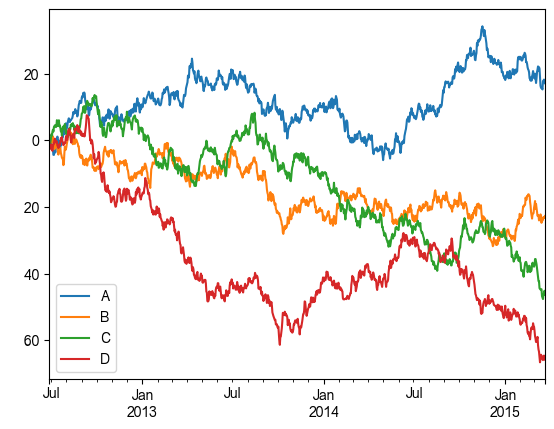

In [167]:
# 线性图
df1 = pd.DataFrame(data = np.random.randn(1000,4),
                  index = pd.date_range(start = '27/6/2012',periods=1000),
                  columns=list('ABCD'))
df1.cumsum().plot() 

<Axes: >

/home/eugene/miniconda3/envs/aicourse/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/home/eugene/miniconda3/envs/aicourse/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


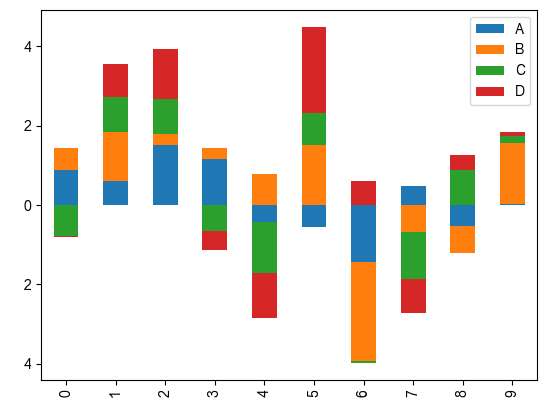

In [168]:
# 条形图
df1 = pd.DataFrame(data = np.random.randn(10,4),
                  columns=list('ABCD'))
df1.plot.bar(stacked = True) # stacked 表示是否堆叠

array([<Axes: ylabel='One'>, <Axes: ylabel='Two'>], dtype=object)

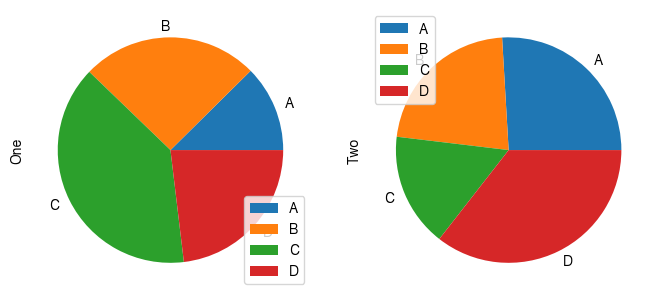

In [169]:
# 饼图
df3 = pd.DataFrame(data = np.random.rand(4,2),
                   index = list('ABCD'),
                   columns=['One','Two'])
df3.plot.pie(subplots = True,figsize = (8,8)) # subplots 表示多个图；figsize 表示尺寸

<Axes: xlabel='A', ylabel='B'>

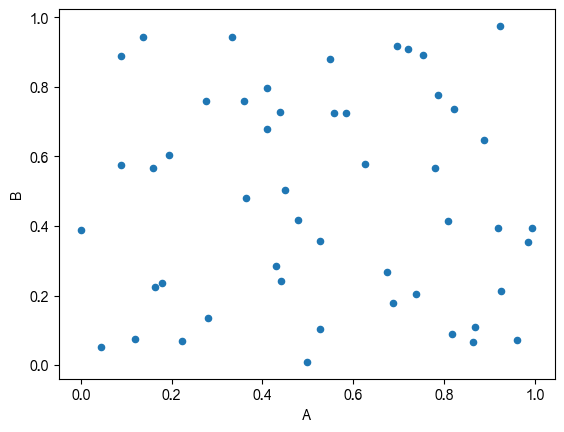

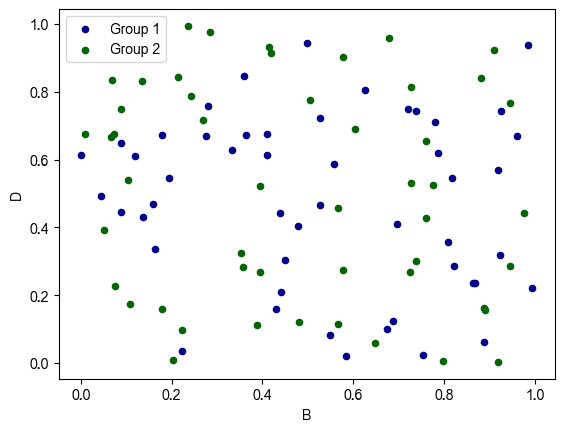

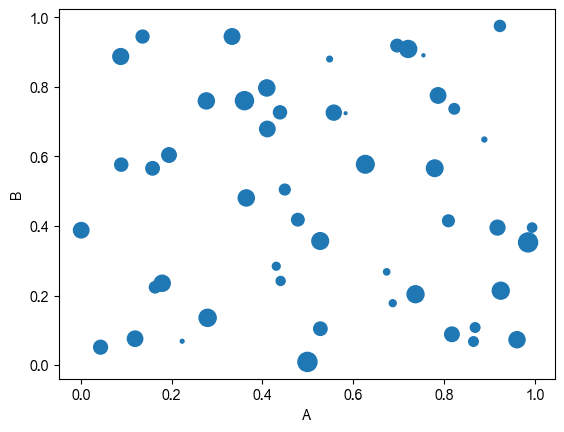

In [170]:
# 散点图

df4 = pd.DataFrame(np.random.rand(50, 4), columns=list('ABCD'))
df4.plot.scatter(x='A', y='B') # A和B关系绘制

# 在一张图中绘制AC散点图，同时绘制BD散点图
ax = df4.plot.scatter(x='A', y='C', color='DarkBlue', label='Group 1');
df4.plot.scatter(x='B', y='D', color='DarkGreen', label='Group 2', ax=ax)

# 气泡图，散点有大小之分
df4.plot.scatter(x='A',y='B',s = df4['C']*200)

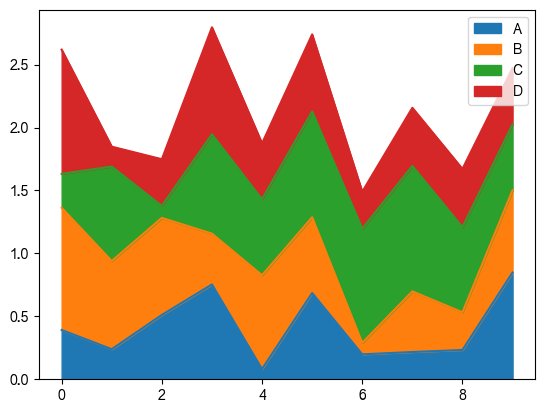

In [171]:
# 面积图

df5 = pd.DataFrame(data = np.random.rand(10, 4), 
                   columns=list('ABCD'))
df5.plot.area(stacked = True);# stacked 是否堆叠

<Axes: >

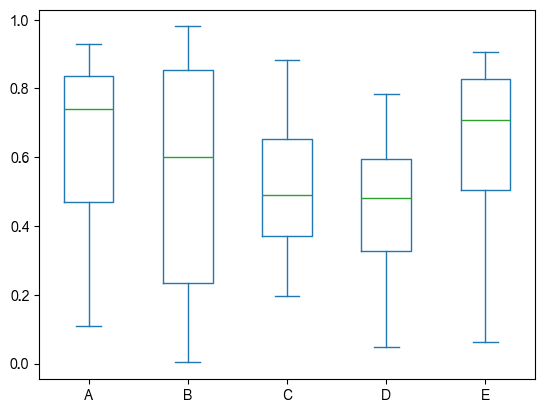

In [172]:
# 箱式图

df6 = pd.DataFrame(data = np.random.rand(10, 5), 
                   columns=list('ABCDE'))
df6.plot.box()

array([[<Axes: title={'center': 'A'}>, <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'C'}>, <Axes: >]], dtype=object)

/home/eugene/miniconda3/envs/aicourse/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/home/eugene/miniconda3/envs/aicourse/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


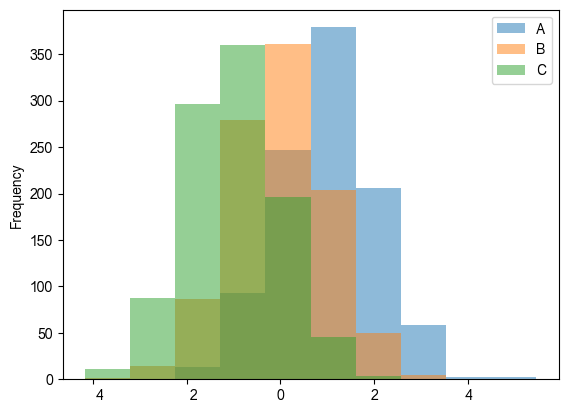

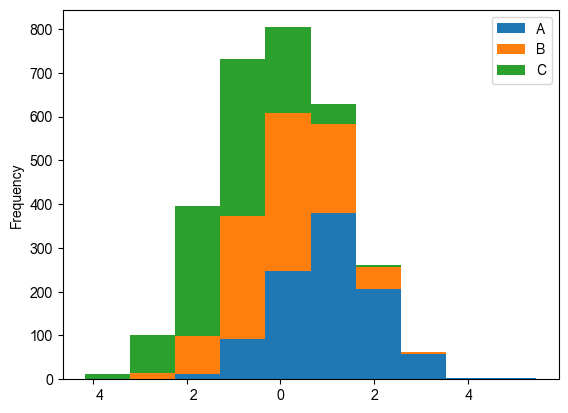

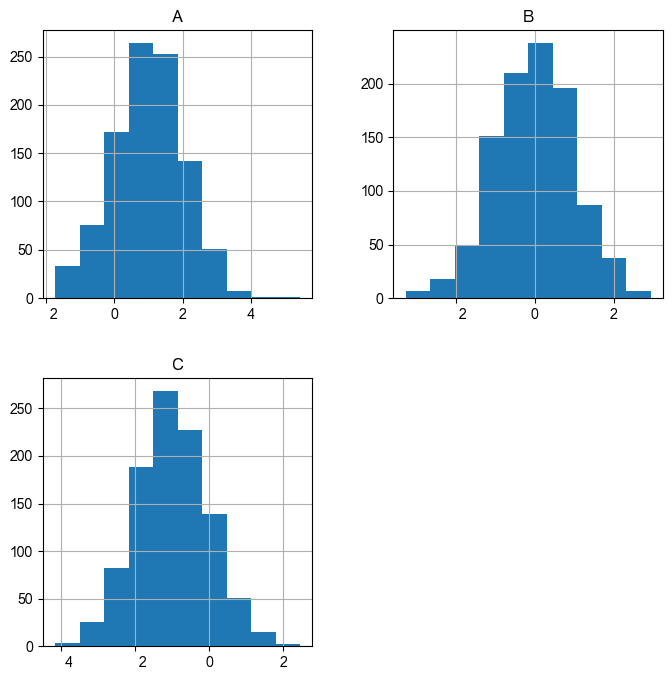

In [173]:
# 直方图
df7 = pd.DataFrame({'A': np.random.randn(1000) + 1,
                    'B': np.random.randn(1000),
                    'C': np.random.randn(1000) - 1})

df7.plot.hist(alpha=0.5) #带透明度直方图

df7.plot.hist(stacked = True)# 堆叠图

df7.hist(figsize = (8,8)) # 子视图绘制

## 作业

In [214]:
df_boys = pd.read_excel('体测分数_男生_女生_处理.xlsx', sheet_name='男生')
df_girls = pd.read_excel('体测分数_男生_女生_处理.xlsx', sheet_name='女生')

### No.1

将一班男生的‘男1000米跑’成绩制成线性图

hint：姓名一列数值后面跟的数字表示班级，需要使用正则表达式提取


In [215]:
import re

def convert(x):
    # return x[3:]
    match = re.search(r'\d+$', x)
    if match:
        return match.group()
    else:
        return '0'

#添加班级列，int16 类型
df_boys['班级'] = df_boys['姓名'].map(convert).astype(np.int16)

cond = df_boys['班级'] == 1
score_of_clz_1 = df_boys[cond][['男1000米跑', '班级']]
score_of_clz_1.head()

,男1000米跑,班级
34,3.53,1
60,3.50,1
77,3.48,1
176,3.55,1
189,4.01,1


In [216]:
#重建索引。因为上边打印的数据行索引不连续
score_of_clz_1 = score_of_clz_1.reset_index()
score_of_clz_1.head()

,index,男1000米跑,班级
0,34,3.53,1
1,60,3.50,1
2,77,3.48,1
3,176,3.55,1
4,189,4.01,1


<class 'pandas.core.series.Series'>


<Axes: >

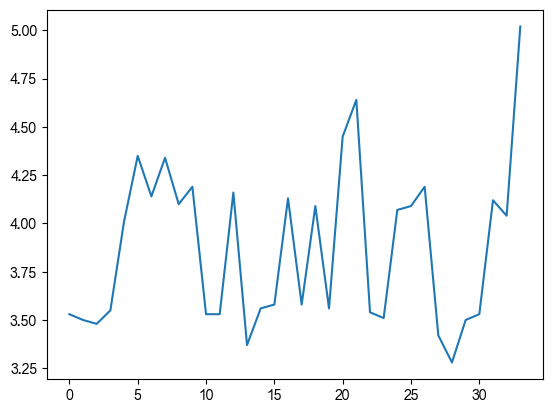

In [217]:
#取出成绩一列进行绘图
score_of_clz_1 = score_of_clz_1['男1000米跑']
print(type(score_of_clz_1))
score_of_clz_1.plot()

### No.2

对各项体侧指标进行分箱操作：不及格（0\~59）、及格（60\~69）、中等(70\~79)、良好(80\~89)、优秀(90\~100)

In [231]:
for col_name in df_boys.columns:
    if not col_name.endswith('分数'):
        continue
    t = pd.cut(df_boys[col_name],
           bins=[0, 60, 70, 80, 90, 100],
           right=False,
           labels=['不及格', '及格', '中等', '良好', '优秀'])
    display(t.value_counts())
    print('---')

男1000米跑分数
中等     422
良好     241
及格     174
不及格    134
优秀      59
Name: count, dtype: int64

---


男50米跑分数
中等     691
及格     182
良好      88
不及格     55
优秀      39
Name: count, dtype: int64

---


男跳远分数
及格     437
中等     365
良好     108
不及格    107
优秀      38
Name: count, dtype: int64

...

---


男引体分数
不及格    359
及格     297
中等     217
良好      92
优秀      74
Name: count, dtype: int64

---


男肺活量分数
良好     234
中等     182
优秀     138
及格      69
不及格     51
Name: count, dtype: int64

---


In [233]:
for col_name in df_girls.columns:
    if not col_name.endswith('分数'):
        continue
    t = pd.cut(df_girls[col_name],
           bins=[0, 60, 70, 80, 90, 100],
           right=False,
           labels=['不及格', '及格', '中等', '良好', '优秀'])
    display(t.value_counts())
    print('---')

女800米跑分数
中等     410
良好     316
优秀     124
不及格    108
及格      83
Name: count, dtype: int64

---


女50米跑分数
及格     624
中等     253
不及格    179
良好      14
优秀       4
Name: count, dtype: int64

---


女跳远分数
及格     529
中等     313
良好     151
不及格     55
优秀      17
Name: count, dtype: int64

...

---


女仰卧分数
中等     609
良好     262
及格     136
不及格     34
优秀      24
Name: count, dtype: int64

---


女肺活量分数
中等     254
良好     184
及格     124
优秀      84
不及格     15
Name: count, dtype: int64

---


### No.3

绘制全校男生1000米跑和男跳远的条形图（分箱操作后统计各个成绩水平数量）

In [239]:
boys_1000m_levels = pd.cut(df_boys['男1000米跑分数'],
       bins=[0, 60, 70, 80, 90, 100],
       right=False,
       labels=['不及格', '及格', '中等', '良好', '优秀'])

boys_jump_levels = pd.cut(df_boys['男跳远分数'],
       bins=[0, 60, 70, 80, 90, 100],
       right=False,
       labels=['不及格', '及格', '中等', '良好', '优秀'])

display(boys_1000m_levels.value_counts(), boys_jump_levels.value_counts())

男1000米跑分数
中等     422
良好     241
及格     174
不及格    134
优秀      59
Name: count, dtype: int64

男跳远分数
及格     437
中等     365
良好     108
不及格    107
优秀      38
Name: count, dtype: int64

<Axes: >

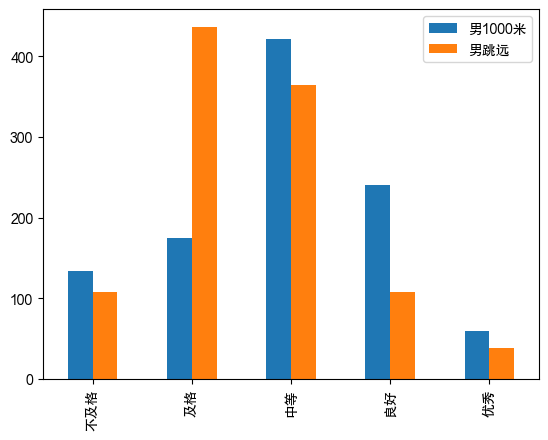

In [243]:
data = pd.DataFrame({
    '男1000米': boys_1000m_levels.value_counts(),
    '男跳远': boys_jump_levels.value_counts(),
})
data.plot.bar()

### No.4

绘制全校女生50米跑和女仰卧的饼图（分箱操作后统计各个成绩水平的数量）

In [250]:
girls_50m_levels = pd.cut(df_girls['女50米跑分数'],
       bins=[0, 60, 70, 80, 90, 100],
       right=False,
       labels=['不及格', '及格', '中等', '良好', '优秀'])

girls_getup_levels = pd.cut(df_girls['女仰卧分数'],
       bins=[0, 60, 70, 80, 90, 100],
       right=False,
       labels=['不及格', '及格', '中等', '良好', '优秀'])

display(girls_50m_levels.value_counts(), girls_getup_levels.value_counts())

女50米跑分数
及格     624
中等     253
不及格    179
良好      14
优秀       4
Name: count, dtype: int64

女仰卧分数
中等     609
良好     262
及格     136
不及格     34
优秀      24
Name: count, dtype: int64

array([<Axes: ylabel='女仰卧'>, <Axes: ylabel='女50米'>], dtype=object)

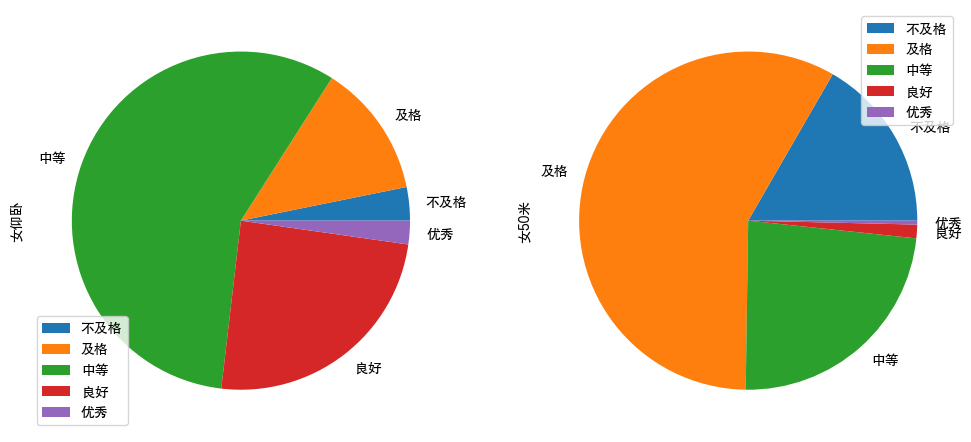

In [260]:
pd.DataFrame({
    '女仰卧': girls_getup_levels.value_counts(),
    '女50米': girls_50m_levels.value_counts()
}).plot.pie(subplots = True, figsize=(12, 6))

### No.5

绘制男跳远、女跳远的堆叠条形图（分箱操作后统计各个成绩水平的数量）

In [267]:
boys_jump_levels = pd.cut(df_boys['男跳远分数'],
       bins=[0, 60, 70, 80, 90, 100],
       right=False,
       labels=['不及格', '及格', '中等', '良好', '优秀'])

girls_jump_levels = pd.cut(df_girls['女跳远分数'],
       bins=[0, 60, 70, 80, 90, 100],
       right=False,
       labels=['不及格', '及格', '中等', '良好', '优秀'])

display(boys_jump_levels.value_counts(), girls_jump_levels.value_counts())

男跳远分数
及格     437
中等     365
良好     108
不及格    107
优秀      38
Name: count, dtype: int64

女跳远分数
及格     529
中等     313
良好     151
不及格     55
优秀      17
Name: count, dtype: int64

<Axes: >

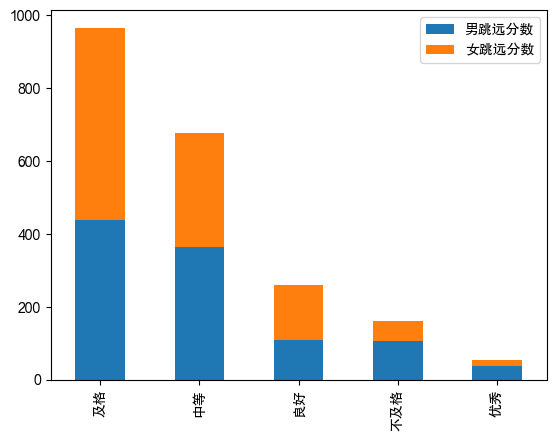

In [265]:
pd.DataFrame({
    '男跳远分数': boys_jump_levels.value_counts(),
    '女跳远分数': girls_jump_levels.value_counts(),
}).plot.bar(stacked = True)